In [2]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import StandardScaler

from os.path import join
import os

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id,download_dir
add_to_path(join(root_dir, 'src'))
import utils.preprocessing as preprocessing
import anomaly_detection.deep_learning.AE as AE
from data_loader import load_data

Added to sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [3]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

Extracted data found at: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [28]:
import utils.visualization as visualisation
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_plot_nparray(df, array, cols, both=False):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    
    if both:
        for ax, col in zip(axes, cols[:nrows * ncols]):
            ax.plot(df["time_real"].values, array[:,cols.index(col)], label="Reconstruit", color="orange")
            ax.legend(loc="upper right", fontsize=8) 
    else:
        for ax, col in zip(axes, cols[:nrows * ncols]):
            ax.plot(df["time_real"].values, df[col].values, label="Réel", color="steelblue", alpha=0.7)
            ax.plot(df["time_real"].values, array[:,cols.index(col)], label="Reconstruit", color="darkorange", linestyle="--")
            
            ax.set_title(col)
            ax.legend(loc="upper right", fontsize=8)
            
    for ax in axes[len(cols):]:
        ax.set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_anomalies(df, anomaly_mask, cols, method="pca", lag=8):
    """
    Visualize anomalies on the original signal

    Parameters
    ----------
    df : pandas DataFrame
        The original dataframe containing the signals and time
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    cols : list of str
        The list of columns to visualize

    Returns
    -------
    None
    """
    # Visualize anomalies
    dff = df.copy()
    if method == "dpca":
        dff = df.iloc[lag:,:].reset_index(drop=True)
    anomaly_times = dff.loc[anomaly_mask, 'time_real']

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
    axes = axes.flatten()

    for ax, col in zip(axes, cols[:nrows * ncols]):

        # original signal plot
        visualisation.plot(dff, 'time_real', col, ax=ax)

        # overlay anomaly points
        ax.scatter(
            anomaly_times,
            dff.loc[anomaly_mask, col],
            color='red',
            s=10,
            label='SPE anomaly',
            zorder=3
        )

        ax.legend(loc="upper right", fontsize=8)

    # hide unused axes
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

def pca_anomaly_detection(df,cols, PCA, SCALER, seuil=None, d=4, method="SPE", clf_IF=None):
    """
    Apply PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    PCA : PCA object
        The trained PCA model
    SCALER : StandardScaler object
        The trained scaler used for PCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    res_pca = PCA.transform(df_center)
    if method == "SPE":
        res_pca[:,d:] = 0
        df_inv = PCA.inverse_transform(res_pca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_pca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

def dpca_anomaly_detection(df,cols, DPCA, SCALER, seuil=None, lag=8, d=4, method="SPE", clf_IF=None):
    """
    Apply dynamic PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    DPCA : PCA object
        The trained dynamic PCA model
    SCALER : StandardScaler object
        The trained scaler used for DPCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    df_center = dynamic_augmentation(df_center, s=lag)
    res_dpca = DPCA.transform(df_center)
    if method == "SPE":
        res_dpca[:,d:] = 0
        df_inv = DPCA.inverse_transform(res_dpca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_dpca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

In [5]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

len(list_session)

40

D'après l'étude faite dans anl02p1-pca on ne garde uniquement les 30 suivantes sessions.

In [6]:
# We only keep normal sessions
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

clean_sessions = [
    k for k in list_session
    if os.path.splitext(os.path.basename(k))[0] not in session_anomaly
]
df_list = []

for cle in clean_sessions:
    df_temp = data_dict[cle].copy()
    df_temp = preprocessing.clean_dataframe(df_temp)
    session_name = os.path.splitext(os.path.basename(cle))[0]
    if 'session_id' not in df_temp.columns:
        df_temp['session_id'] = session_name
    df_list.append(df_temp)

df_filtered = pd.concat(df_list, ignore_index=True)


print(f"Données chargées. Dimensions : {df_filtered.shape}")
print(f"Nombre de sessions saines : {df_filtered['session_id'].nunique()}")
display(df_filtered.head())


Données chargées. Dimensions : (289405, 18)
Nombre de sessions saines : 30


,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2,time_real,session_id
0,2024-05-03 22:49:36.502,1916.29,2035.22,2010.47,1983.84,4250.50,4300.35,7630.84,8613.12,4.17052,2.57613,0.985107,-0.180691,-0.472259,248.967,-2.387850,0.00,T24S12-04_E-AL2870
1,2024-05-03 22:49:36.512,1916.29,2036.40,2017.03,1987.99,4000.12,4255.14,7768.87,9137.16,4.42023,2.31616,0.952778,-0.275728,-0.823481,249.055,0.157031,0.01,T24S12-04_E-AL2870
2,2024-05-03 22:49:36.522,1919.14,2041.12,2013.75,1993.19,4080.10,3708.03,8209.24,9542.19,3.98324,2.46781,0.880037,-0.156931,-0.608216,249.232,-1.916580,0.02,T24S12-04_E-AL2870
3,2024-05-03 22:49:36.532,1920.09,2036.40,2013.75,1986.96,3585.15,3214.24,8666.04,9658.90,4.07688,2.51114,0.742637,-0.014376,-1.118060,249.321,-1.508140,0.03,T24S12-04_E-AL2870
4,2024-05-03 22:49:36.542,1920.09,2041.12,2020.31,1991.11,3347.52,3361.45,8725.20,9462.10,4.23295,2.26200,0.758802,-0.145052,-0.959439,249.498,-3.204730,0.04,T24S12-04_E-AL2870


Séparation en un jeu d'entrainement et un jeu de test 

In [7]:

all_sessions = df_filtered['session_id'].unique()

# random selection of 6 sessions (20% of 30)
random.seed(40)
test_sessions = random.sample(list(all_sessions), 6)
train_sessions = [s for s in all_sessions if s not in test_sessions]

print(f"Sessions d'entraînement : {train_sessions}")
print(f"Sessions de test : {test_sessions}")

df_train = df_filtered[df_filtered['session_id'].isin(train_sessions)].copy()
df_test = df_filtered[df_filtered['session_id'].isin(test_sessions)].copy()


Sessions d'entraînement : ['T24S12-04_E-AL2870', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3033', 'T24S12-04_E-AL3070', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3339', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499', 'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690']
Sessions de test : ['T24S12-04_E-AL3319', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3143']


In [8]:

features = [c for c in df_filtered.columns if c not in ['session_id', 'time_real', 'datetime']]

#Standandardization of the datasets
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

In [9]:
# With overlapping of sequences (step of 1)
def create_sequences(df_input, features_list, time_steps):
    sequences_list = []
    data_all = df_input[features_list].values.astype('float32')
    session_ids = df_input['session_id'].values

    for session in df_input['session_id'].unique():
        # Masque pour isoler la session
        mask = (session_ids == session)
        session_data = data_all[mask]

        for i in range(len(session_data) - time_steps + 1):
            sequences_list.append(session_data[i : i + time_steps])
            
    return np.array(sequences_list, dtype='float32')




In [10]:
TIME_STEPS = 5

x_train = create_sequences(df_train, features, TIME_STEPS)
x_test = create_sequences(df_test, features, TIME_STEPS)

print(f"Shape x_train : {x_train.shape}")
print(f"Shape x_test : {x_test.shape}")

Shape x_train : (231951, 5, 15)
Shape x_test : (57334, 5, 15)


Pour savoir quelle taille optimal l'espace latent doit être nous allons réaliser 12 modèles différents avec 12 dimentions différentes:
2,4,6,8,10,12,16,20, 24,28,32,36



In [ ]:

latent_values = [2,4,6,8,10,12,16,20,24,28,32,36]
time_steps = 5
nb_features = len(features)
results = {}

print(f"Début des tests | Input: {time_steps * nb_features} neurones")
print("-" * 50)

for val in latent_values:
    print(f"\n Construction du modèle [Latent: {val}]...")
    model = AE.build_dnn_ae(time_steps, nb_features, latent_dim=val)
    

    history = model.fit(
        x_train, x_train,
        epochs=30,           
        batch_size=64,     
        validation_split=0.1,
        verbose=0           
    )
    
    # Stockage
    final_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    results[val] = {
        'model': model,
        'history': history.history
    }
    
    print(f" Terminé | Loss: {final_loss:.6f} | Val_Loss: {final_val_loss:.6f}")



Début des tests | Input: 75 neurones
--------------------------------------------------

 Construction du modèle [Latent: 2]...
 Terminé | Loss: 0.062272 | Val_Loss: 0.066817

 Construction du modèle [Latent: 4]...
 Terminé | Loss: 0.034316 | Val_Loss: 0.037432

 Construction du modèle [Latent: 6]...
 Terminé | Loss: 0.024965 | Val_Loss: 0.027974

 Construction du modèle [Latent: 8]...
 Terminé | Loss: 0.025166 | Val_Loss: 0.027794

 Construction du modèle [Latent: 10]...
 Terminé | Loss: 0.015971 | Val_Loss: 0.017857

 Construction du modèle [Latent: 12]...
 Terminé | Loss: 0.011624 | Val_Loss: 0.013185

 Construction du modèle [Latent: 16]...
 Terminé | Loss: 0.007770 | Val_Loss: 0.009499

 Construction du modèle [Latent: 20]...
 Terminé | Loss: 0.005322 | Val_Loss: 0.006682

 Construction du modèle [Latent: 24]...
 Terminé | Loss: 0.004138 | Val_Loss: 0.005335

 Construction du modèle [Latent: 28]...
 Terminé | Loss: 0.002779 | Val_Loss: 0.002943

 Construction du modèle [Latent: 32

# Comparaison des modèles

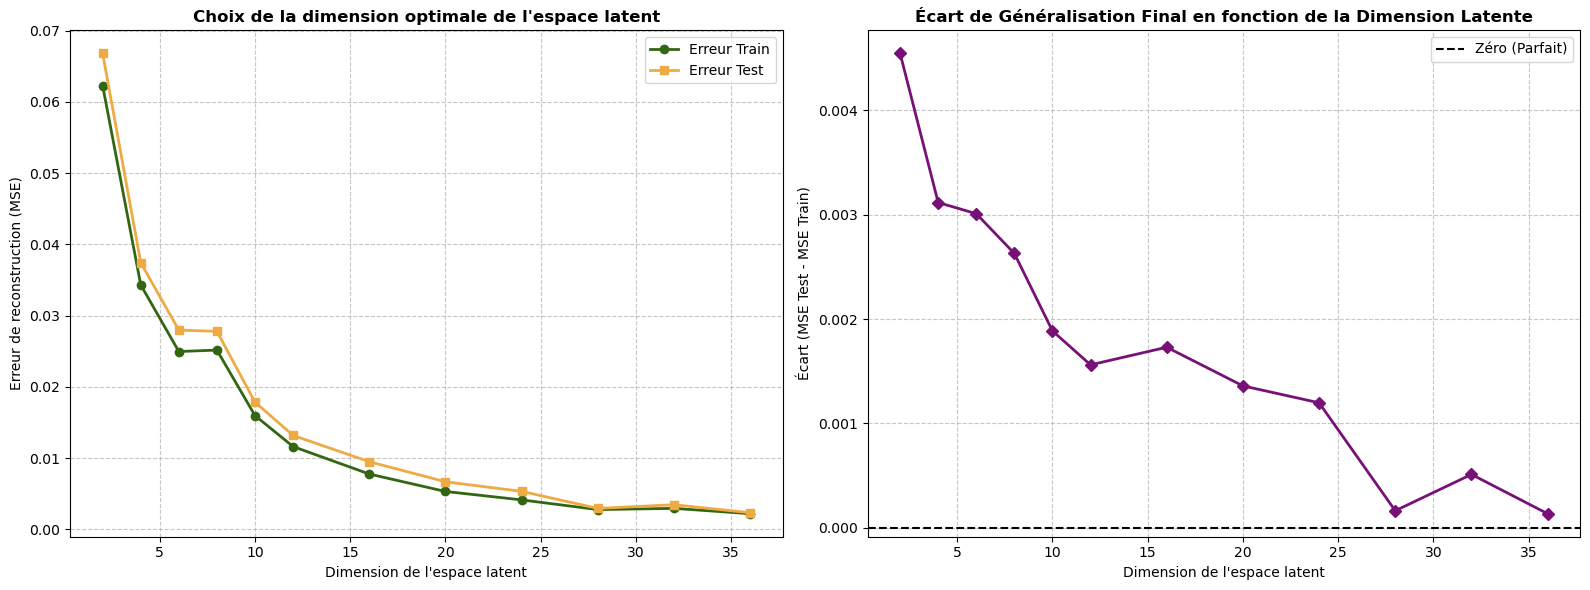

In [ ]:
# On récupère les données triées
latents = sorted(results.keys())
train_losses = [results[l]['history']['loss'][-1] for l in latents]
val_losses = [results[l]['history']['val_loss'][-1] for l in latents]
gap = [v - t for t, v in zip(train_losses, val_losses)]

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPHE 1 : CHOIX DE LA DIMENSION OPTIMALE ---
ax1.plot(latents, train_losses, 'o-', color='#336611', label='Erreur Train', linewidth=2)
ax1.plot(latents, val_losses, 's-', color='#EEAA44', label='Erreur Test', linewidth=2)
ax1.set_title("Choix de la dimension optimale de l'espace latent", fontweight='bold')
ax1.set_xlabel("Dimension de l'espace latent")
ax1.set_ylabel("Erreur de reconstruction (MSE)")
ax1.legend()

# --- GRAPHE 2 : ÉCART DE GÉNÉRALISATION ---
ax2.plot(latents, gap, 'D-', color='#771177', linewidth=2)
ax2.axhline(0, color='black', linestyle='--', label='Zéro (Parfait)')
ax2.set_title("Écart de Généralisation Final en fonction de la Dimension Latente", fontweight='bold')
ax2.set_xlabel("Dimension de l'espace latent")
ax2.set_ylabel("Écart (MSE Test - MSE Train)")
ax2.legend()

plt.tight_layout()
plt.show()

# Entrainement du modèle retenu

In [19]:
final_history_model = AE.build_dnn_ae(time_steps, nb_features, latent_dim=16)
history = final_history_model.fit(
    x=x_train, 
    y=x_train,            
    epochs=50,            
    batch_size=256,       
    validation_split=0.3,
)
final_history_model.summary()

Epoch 1/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1057 - val_loss: 0.0333
Epoch 2/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0261 - val_loss: 0.0249
Epoch 3/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0185 - val_loss: 0.0195
Epoch 4/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0133 - val_loss: 0.0139
Epoch 5/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0112 - val_loss: 0.0124
Epoch 6/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0099 - val_loss: 0.0115
Epoch 7/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0094 - val_loss: 0.0109
Epoch 8/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0089 - val_loss: 0.0106
Epoch 9/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0087 - val_loss: 0.0104
Epoch 10/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0084 - val_loss: 0.0099
Epoch 11/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0080 - val_loss: 0.0097
Epoch 12/50
635/635 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model: "DNN_AE_Latent_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 64)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 75)             │         4,875 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_17 (Reshape)            │ (None, 5, 15)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,011 (175.83 KB)

 Trainable params: 15,003 (58.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,008 (117.22 KB)

In [14]:
import os
import joblib
from tensorflow.keras.models import load_model
final_history_model= load_model('models/autoencoder_history.keras')
scaler = joblib.load('models/scaler_autoencoder_history.pkl')

# détermination des seuils dynamiques

In [15]:
X_pred_train_3D = final_history_model.predict(x_train)

actuel_train_2D = x_train[:, -1, :]
pred_train_2D = X_pred_train_3D[:, -1, :]

mse_train = np.power(actuel_train_2D - pred_train_2D, 2)

seuils_dynamiques = np.percentile(mse_train,99.7, axis=0)


for capteur, seuil in zip(features, seuils_dynamiques):
    print(f"{capteur.ljust(20)} : MSE = {seuil:.6f}")

7249/7249 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
nwl1                 : MSE = 0.015731
nwl2                 : MSE = 0.012438
nwl3                 : MSE = 0.015612
nwl4                 : MSE = 0.017764
fprd1                : MSE = 0.442873
fprd2                : MSE = 0.383863
fprd3                : MSE = 0.465605
fprd4                : MSE = 0.340808
pstr1                : MSE = 0.295685
pstr3                : MSE = 0.263703
astrw                : MSE = 0.026384
g2                   : MSE = 0.152580
ny                   : MSE = 0.069499
vcrf                 : MSE = 0.010862
v2                   : MSE = 0.018833


# Test du modèle 

## Sur une seule sessions du jeux de données test

In [16]:


def get_aligned_df(df_in, time_steps=5):
    # On groupe par session et on enlève les (time_steps-1) premiers points de chacune
    return df_in.groupby('session_id').apply(lambda x: x.iloc[time_steps-1:]).reset_index(drop=True)


1792/1792 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


C:\Users\fauli\AppData\Local\Temp\ipykernel_22780\2438182869.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_in.groupby('session_id').apply(lambda x: x.iloc[time_steps-1:]).reset_index(drop=True)


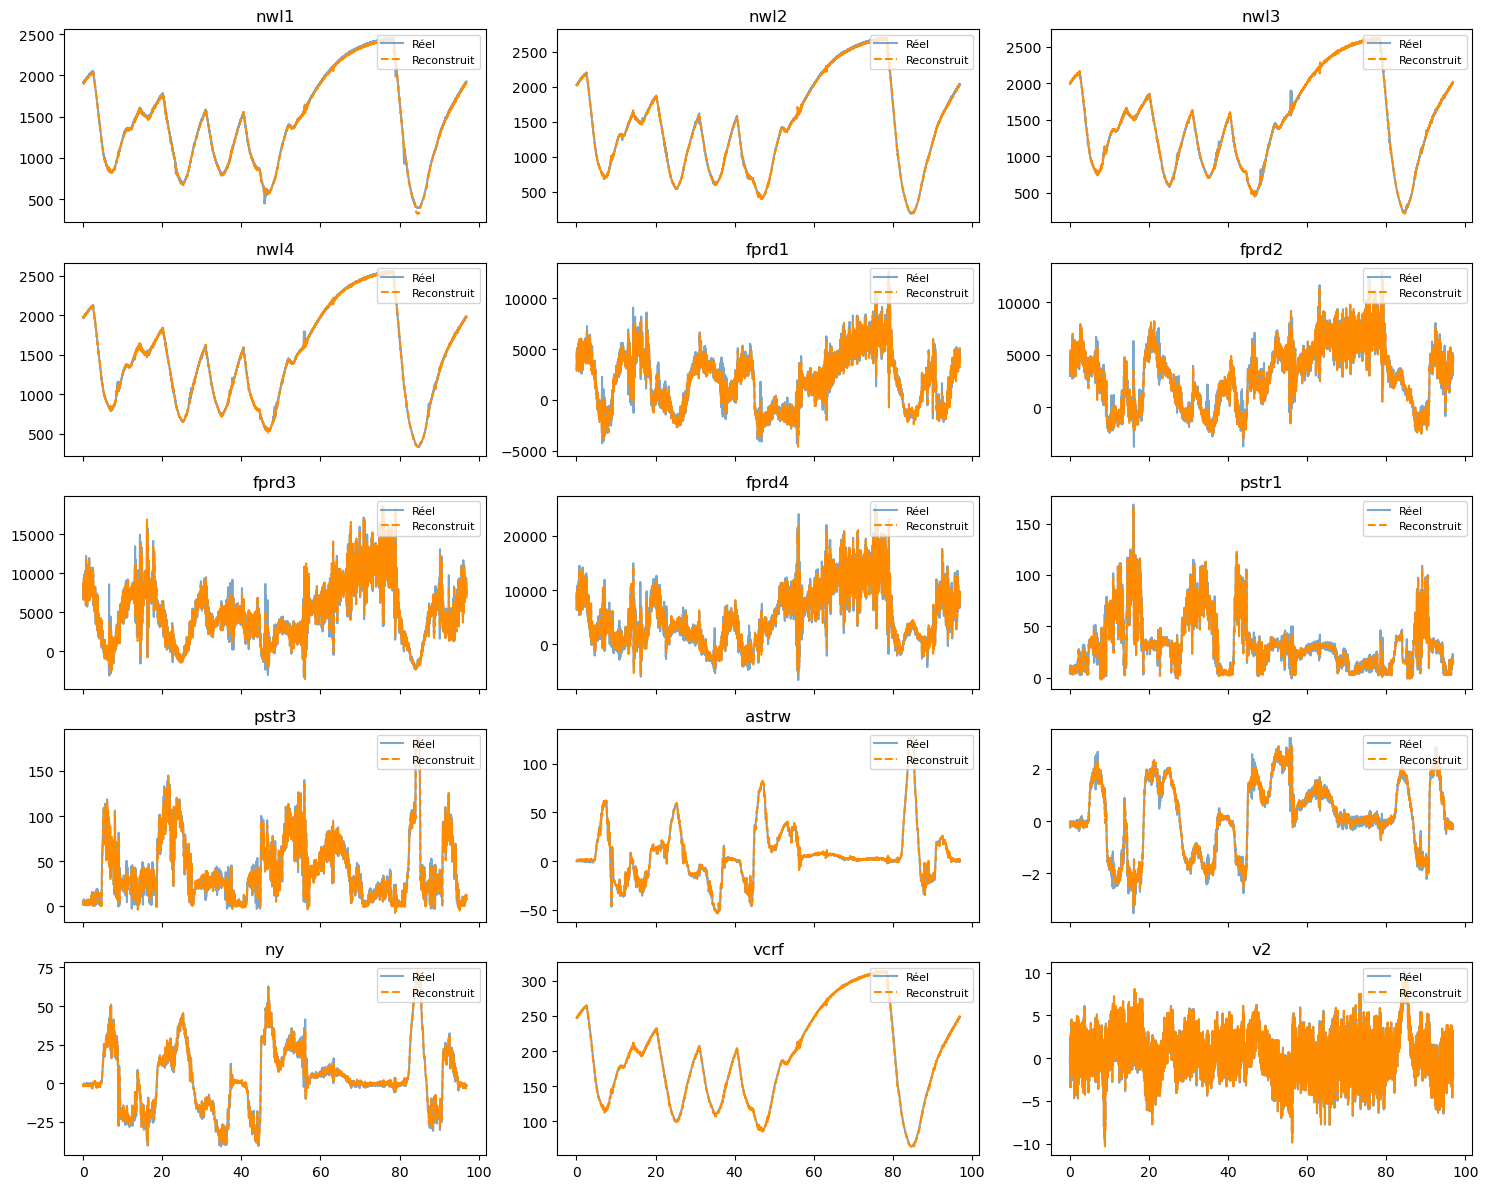

In [17]:
X_pred_test = final_history_model.predict(x_test)

n_s, n_t, n_f = X_pred_test.shape
X_pred_2D = X_pred_test.reshape(-1, n_f)
X_pred_unscaled_2D = scaler.inverse_transform(X_pred_2D)
X_pred_unscaled_3D = X_pred_unscaled_2D.reshape(n_s, n_t, n_f)


X_pred_final_all = X_pred_unscaled_3D[:, -1, :] # Shape: (N, 15)



df_real_scale = df_test.copy()
df_real_scale[features] = scaler.inverse_transform(df_test[features])



df_plot_all = get_aligned_df(df_real_scale)


target_session = df_plot_all['session_id'].unique()[2] 

mask_session = df_plot_all['session_id'] == target_session

df_final_session = df_plot_all[mask_session]
X_pred_session = X_pred_final_all[mask_session.values]

visualisation_plot_nparray(df_final_session, X_pred_session, features, both=False)

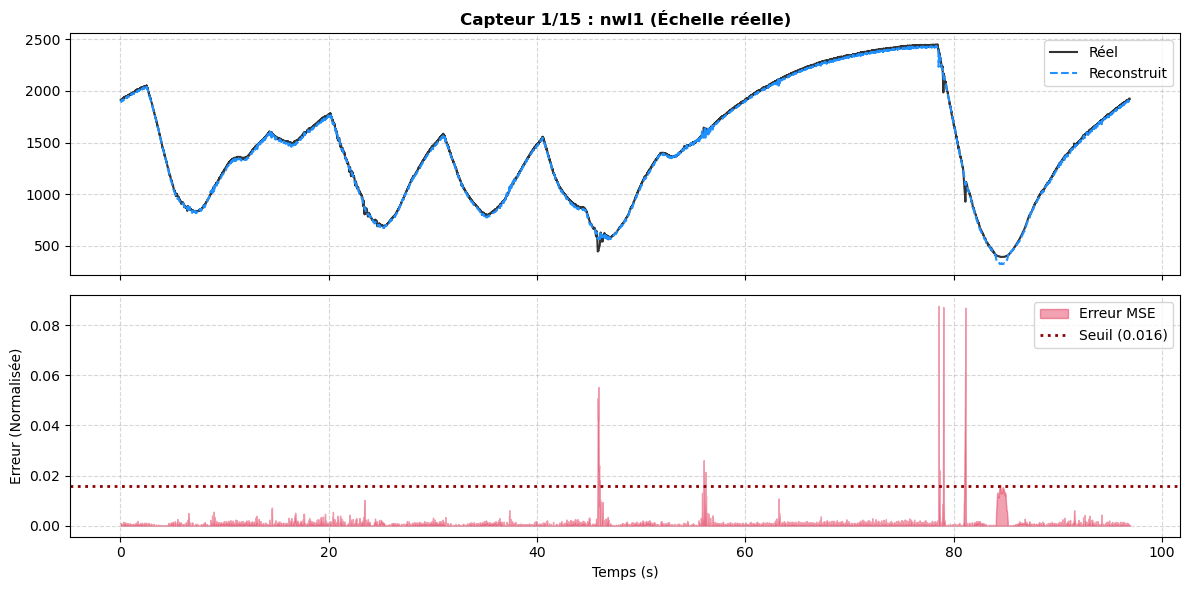

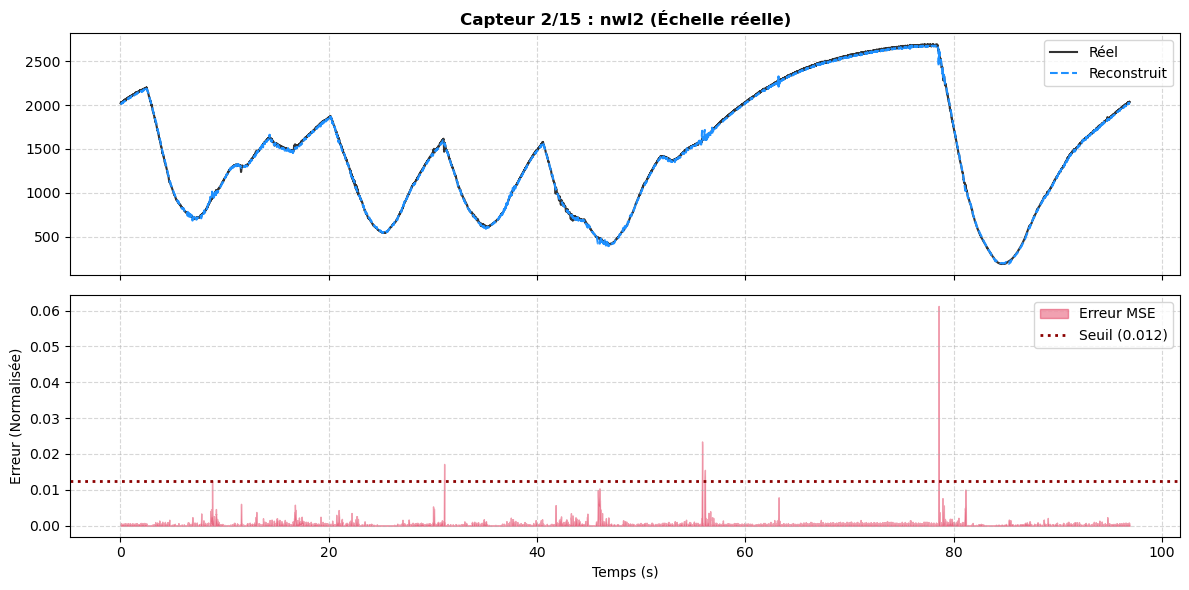

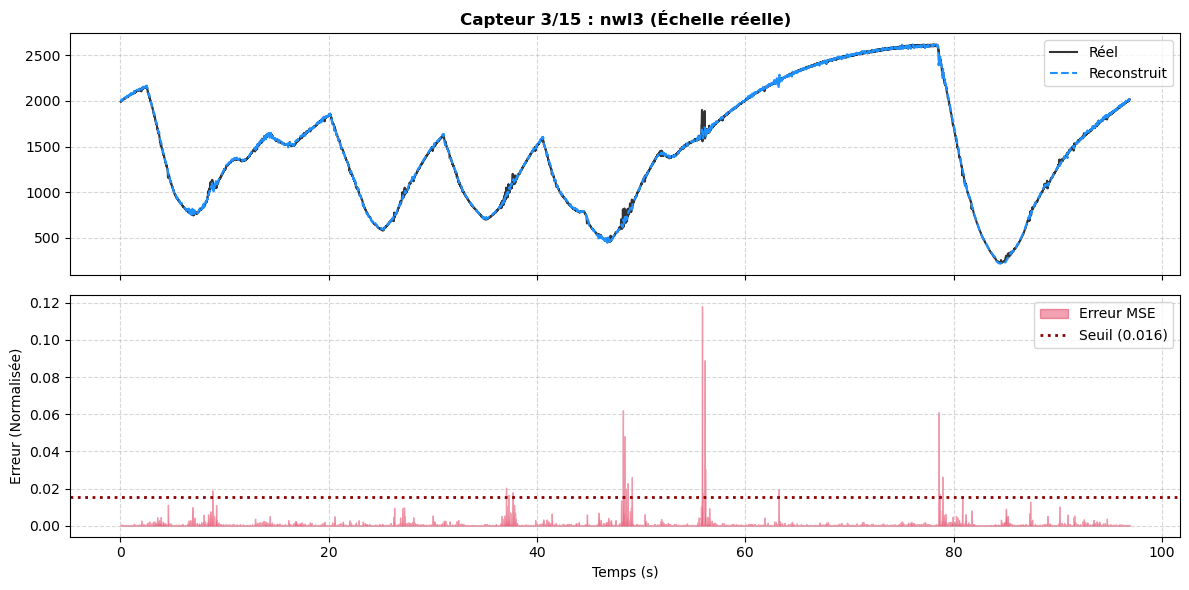

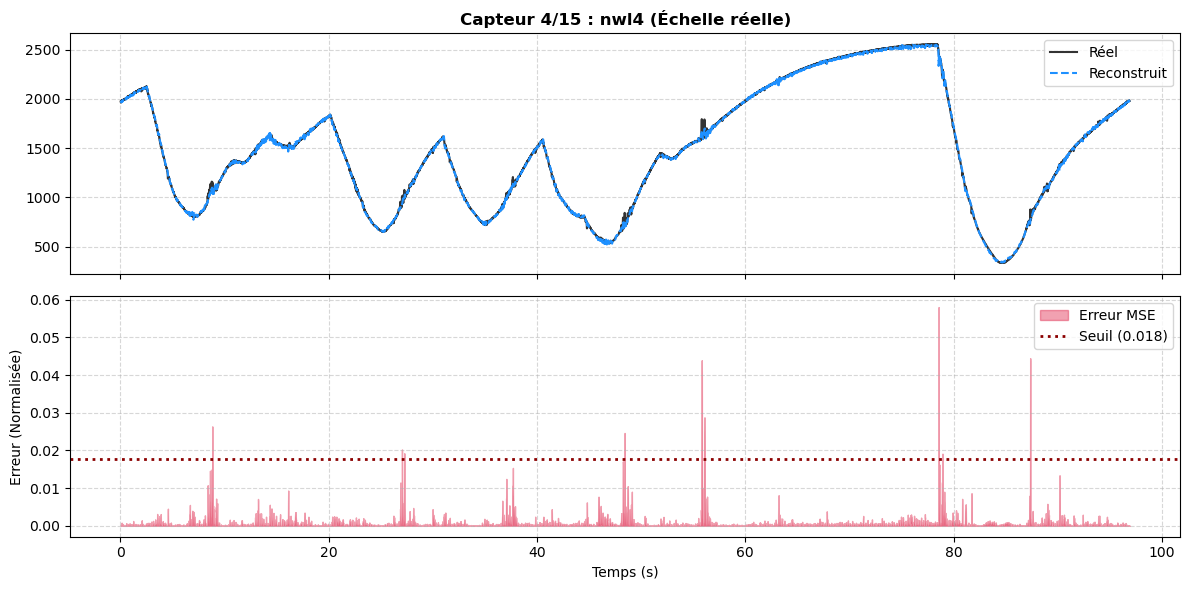

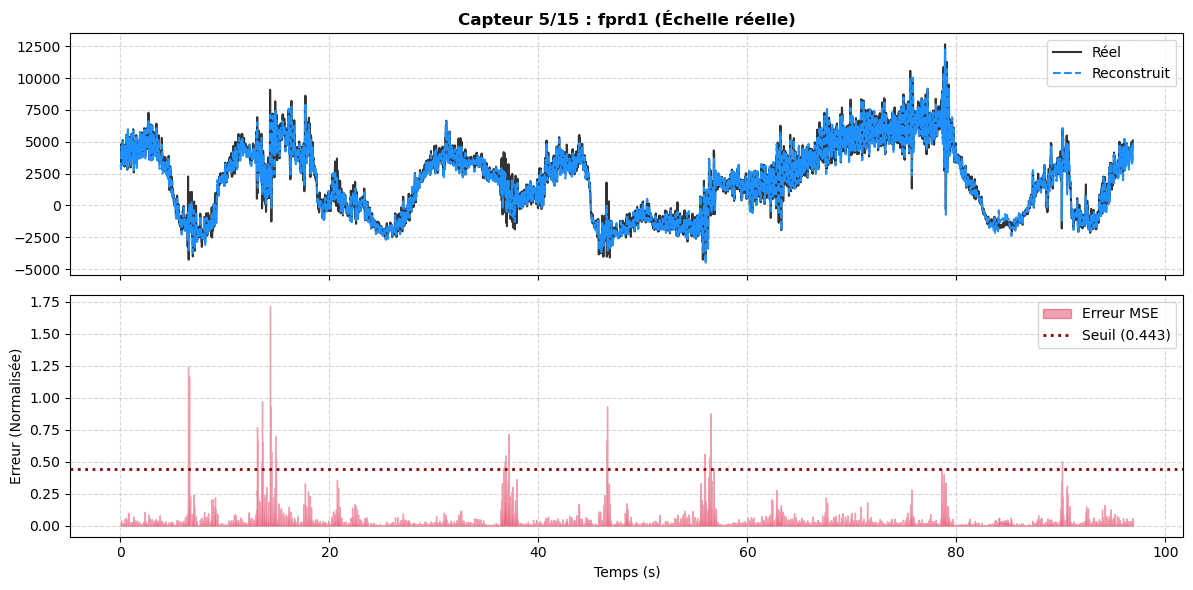

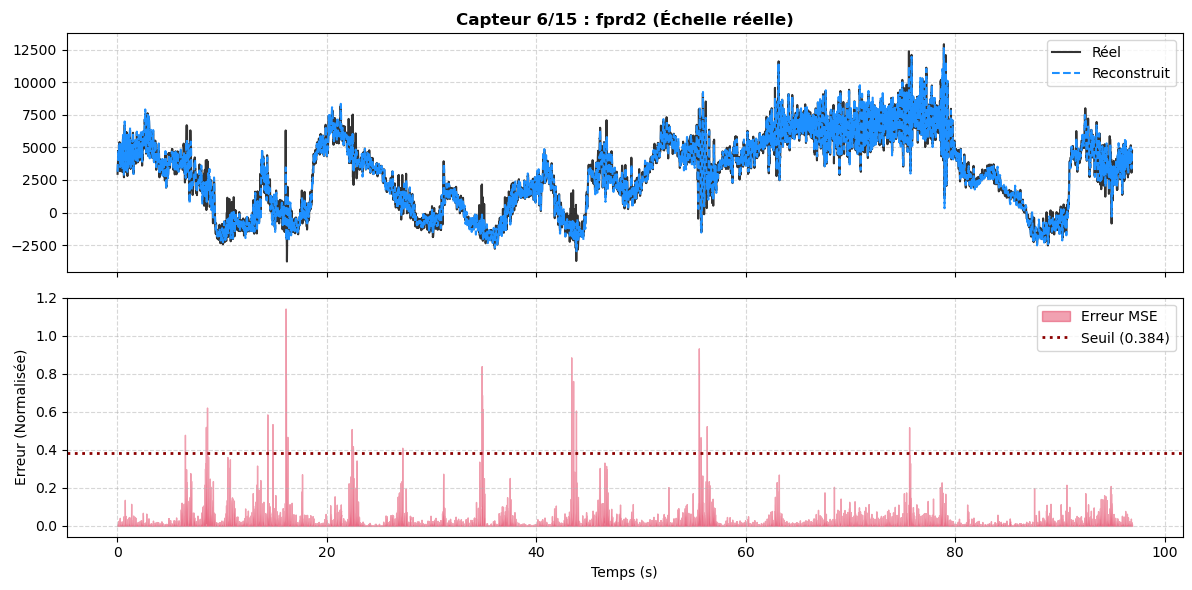

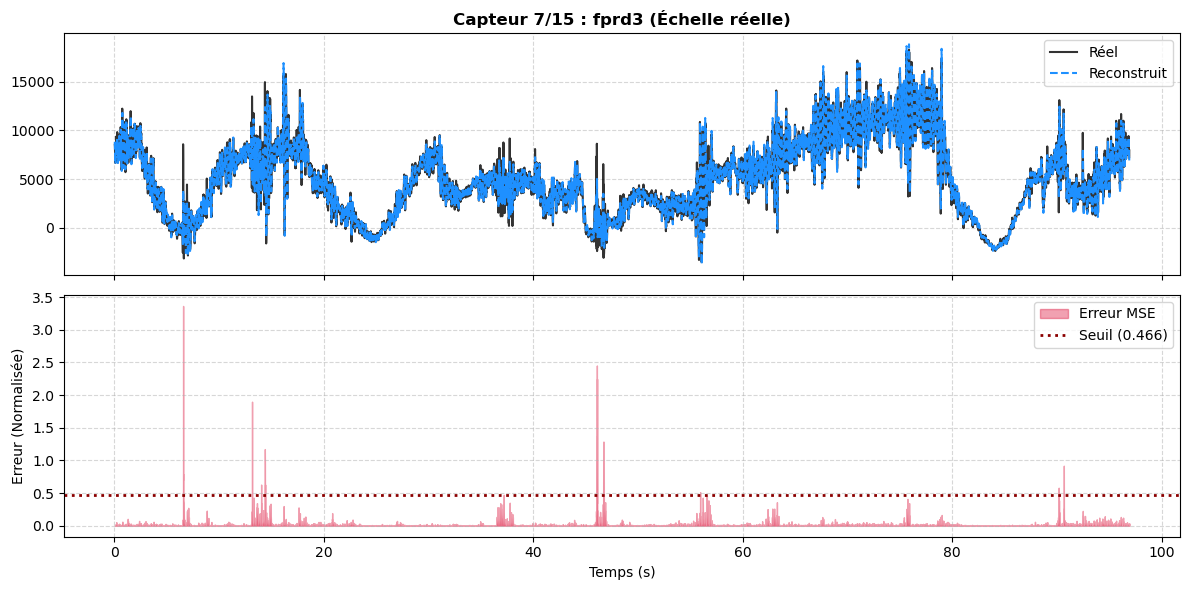

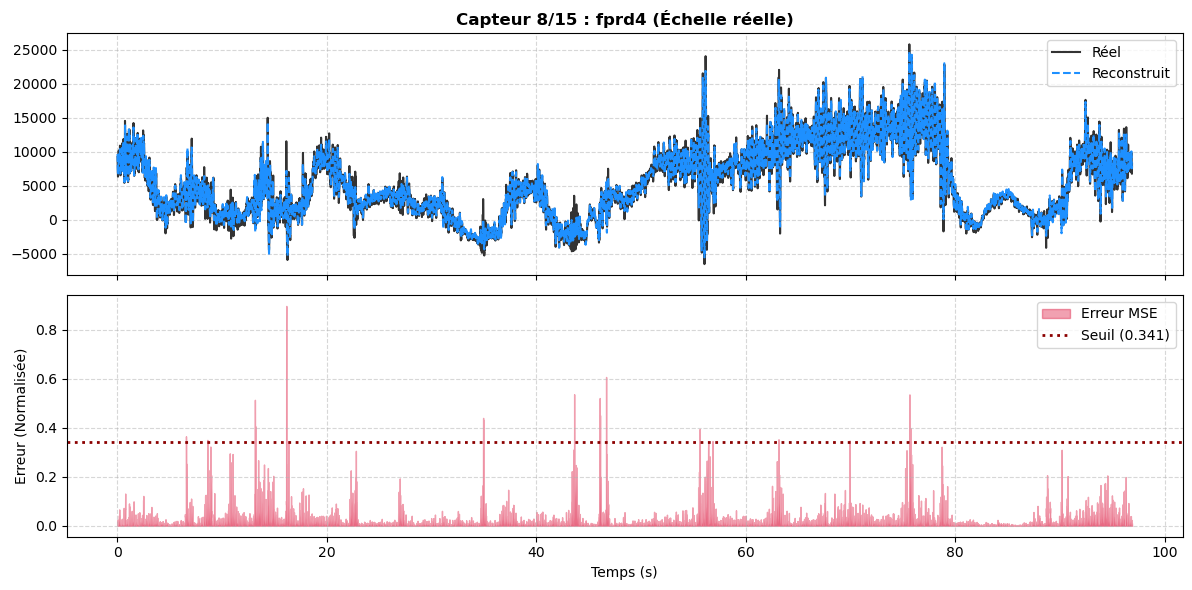

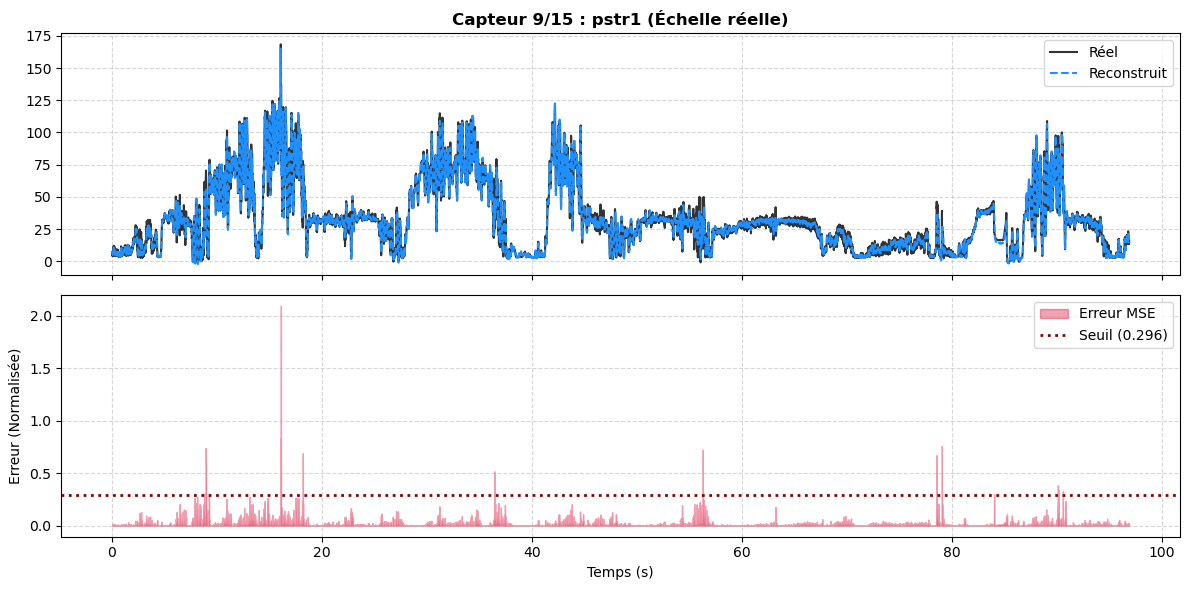

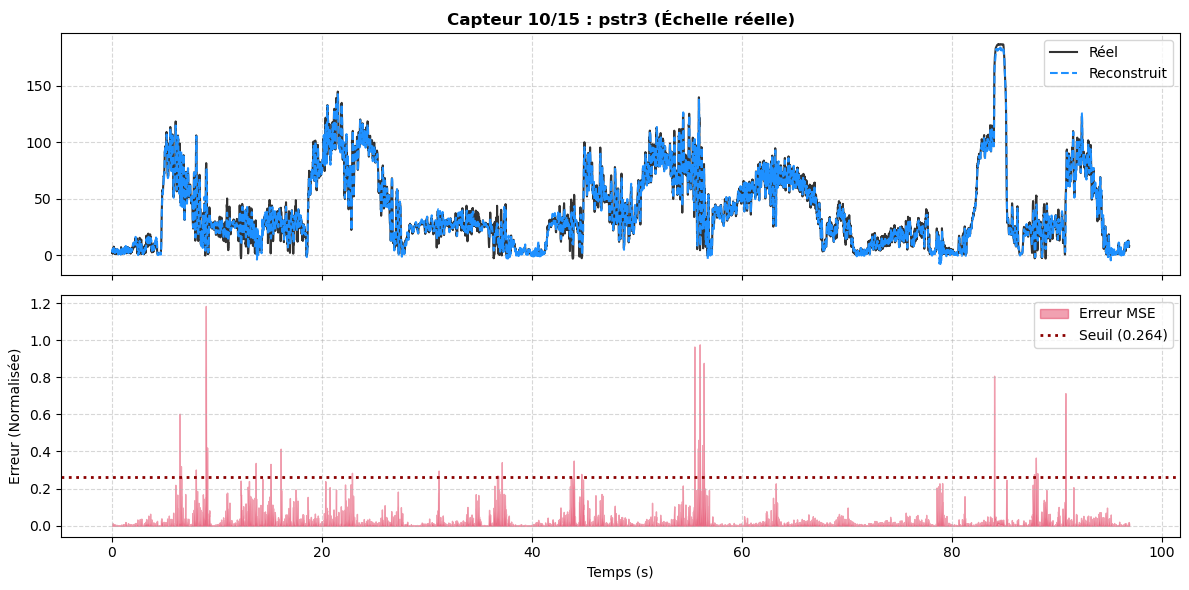

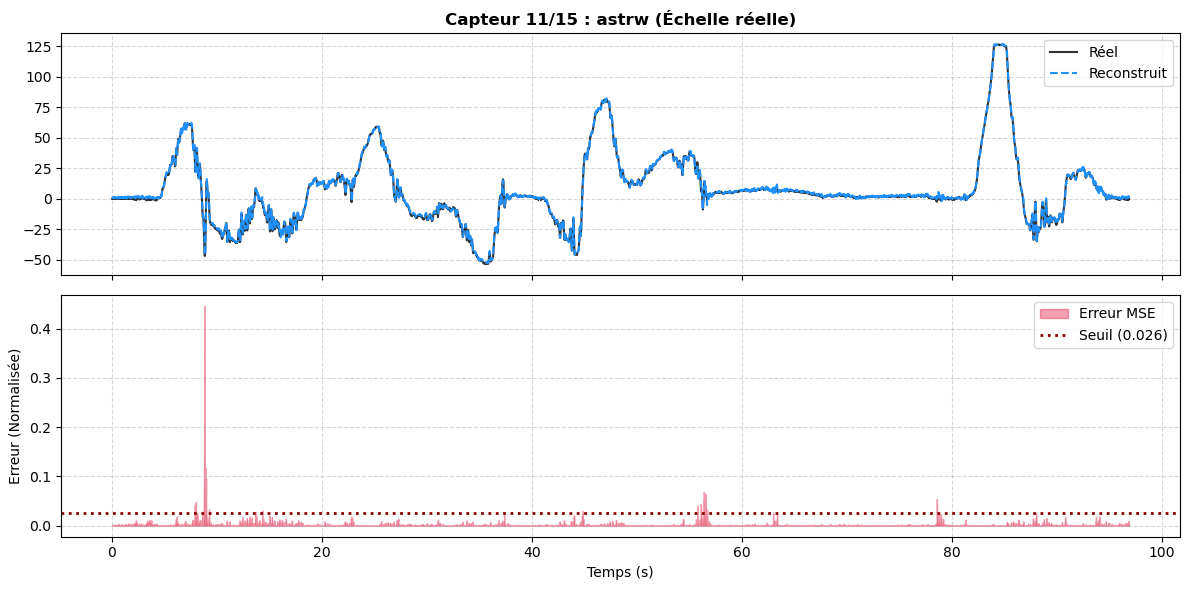

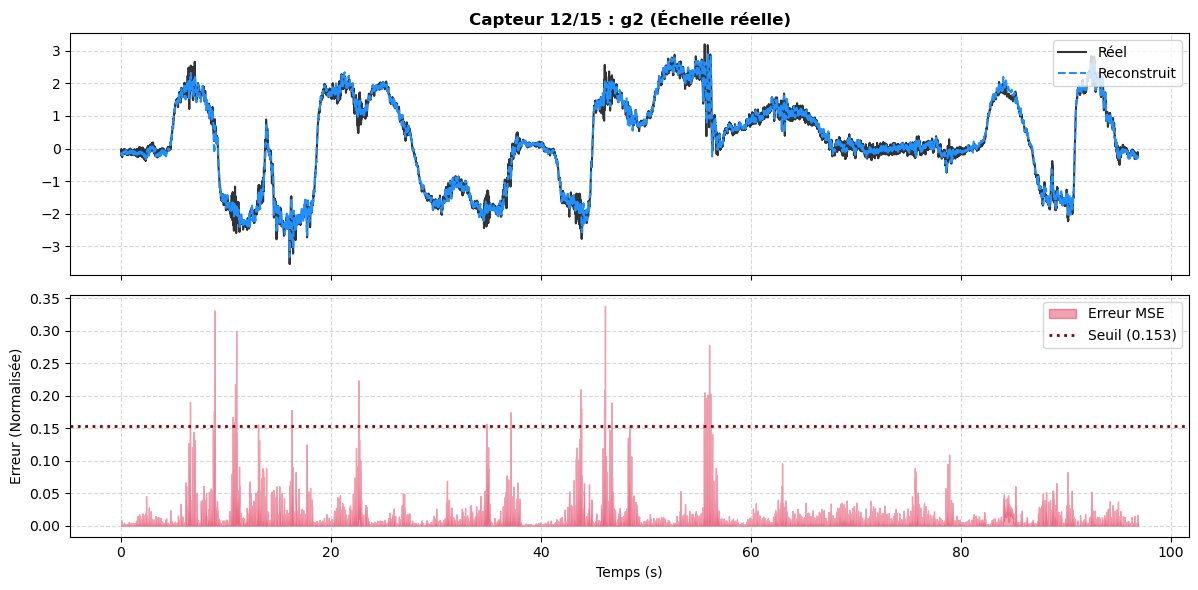

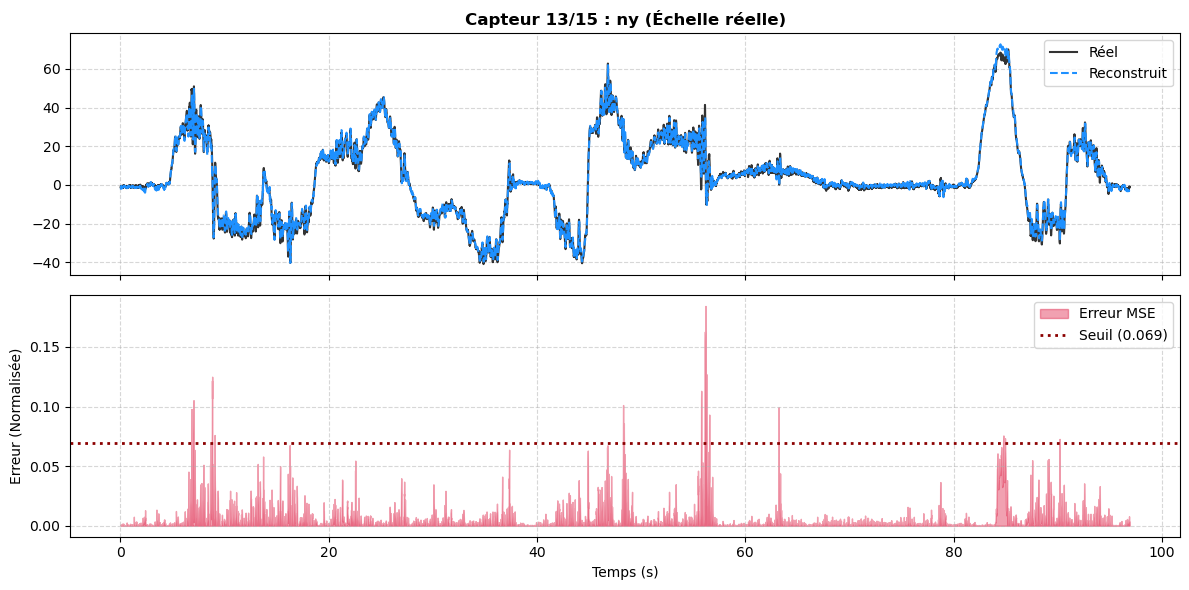

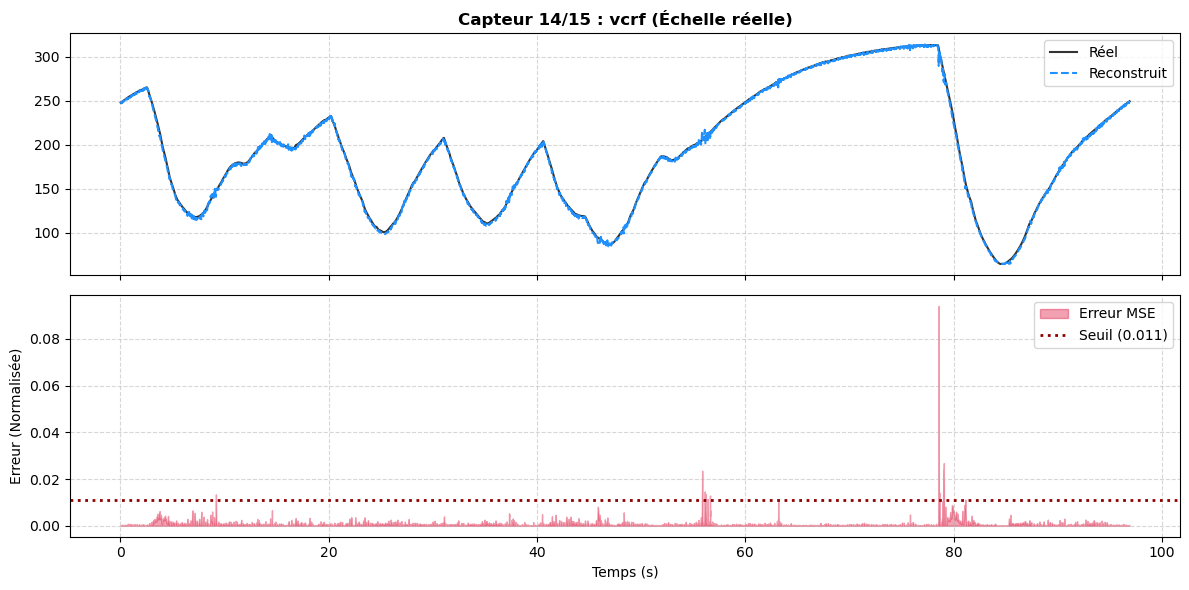

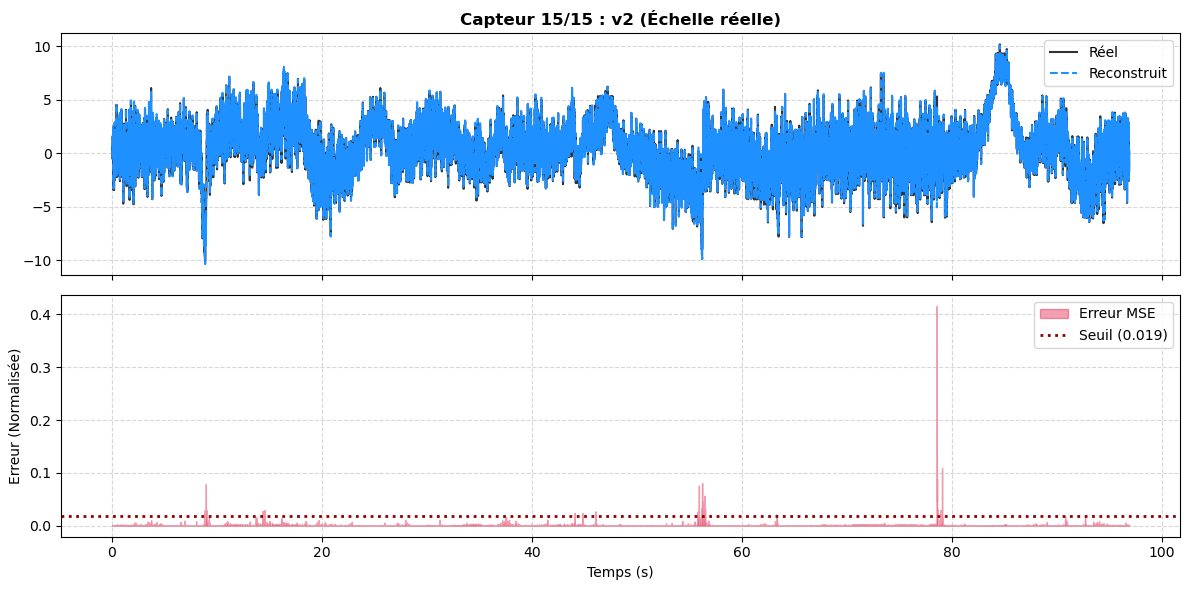

In [18]:

X_reel_norm_session = x_test[mask_session.values, -1, :]
X_pred_norm_session = X_pred_test[mask_session.values, -1, :]

for idx, capteur in enumerate(features):
    
    signal_reel_physique = df_final_session[capteur].values
    signal_reconstruit_physique = X_pred_session[:, idx]
    
  
    signal_reel_norm = X_reel_norm_session[:, idx]
    signal_reconstruit_norm = X_pred_norm_session[:, idx]
    
    erreur_locale_mse = np.power(signal_reel_norm - signal_reconstruit_norm, 2)
    seuil_actuel = seuils_dynamiques[idx]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # --- GRAPHIQUE HAUT : Signaux Physiques ---
    ax1.plot(df_final_session['time_real'], signal_reel_physique, label='Réel', color='black', alpha=0.8)
    ax1.plot(df_final_session['time_real'], signal_reconstruit_physique, label='Reconstruit', color='dodgerblue', linestyle='--')
    ax1.set_title(f"Capteur {idx + 1}/{len(features)} : {capteur} (Échelle réelle)", fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # --- GRAPHIQUE BAS : Erreur et Détection ---
    ax2.fill_between(df_final_session['time_real'], erreur_locale_mse, color='crimson', alpha=0.4, label='Erreur MSE')
    ax2.axhline(y=seuil_actuel, color='darkred', linestyle=':', linewidth=2, label=f'Seuil ({seuil_actuel:.3f})')
    

        
    ax2.set_ylabel("Erreur (Normalisée)")
    ax2.set_xlabel("Temps (s)")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [19]:
def visualisation_anomalies_locales_3D(df, alertes_matrice, features):
    """
    Affiche les 15 capteurs. 
    Les points rouges n'apparaissent QUE sur le capteur responsable du dépassement de seuil.
    """
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 14), sharex=True)
    axes = axes.flatten()

    for idx, (ax, capteur) in enumerate(zip(axes, features)):
        
  
        ax.plot(df['time_real'], df[capteur], color='steelblue', alpha=0.8, linewidth=1.5, label='Signal Réel')
        

        masque_local = alertes_matrice[:, idx]
        
        temps_anomalie = df['time_real'][masque_local]
        valeurs_anomalie = df[capteur][masque_local]
        
        # Si le capteur a des anomalies, on met les points rouges
        if len(temps_anomalie) > 0:
            ax.scatter(temps_anomalie, valeurs_anomalie, color='red', s=20, zorder=3, label='Anomalie détectée')
        
        ax.set_title(f"Capteur : {capteur}", fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        
       
        if idx == 0:
            ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

Total des anomalies détectées sur cette session : 354


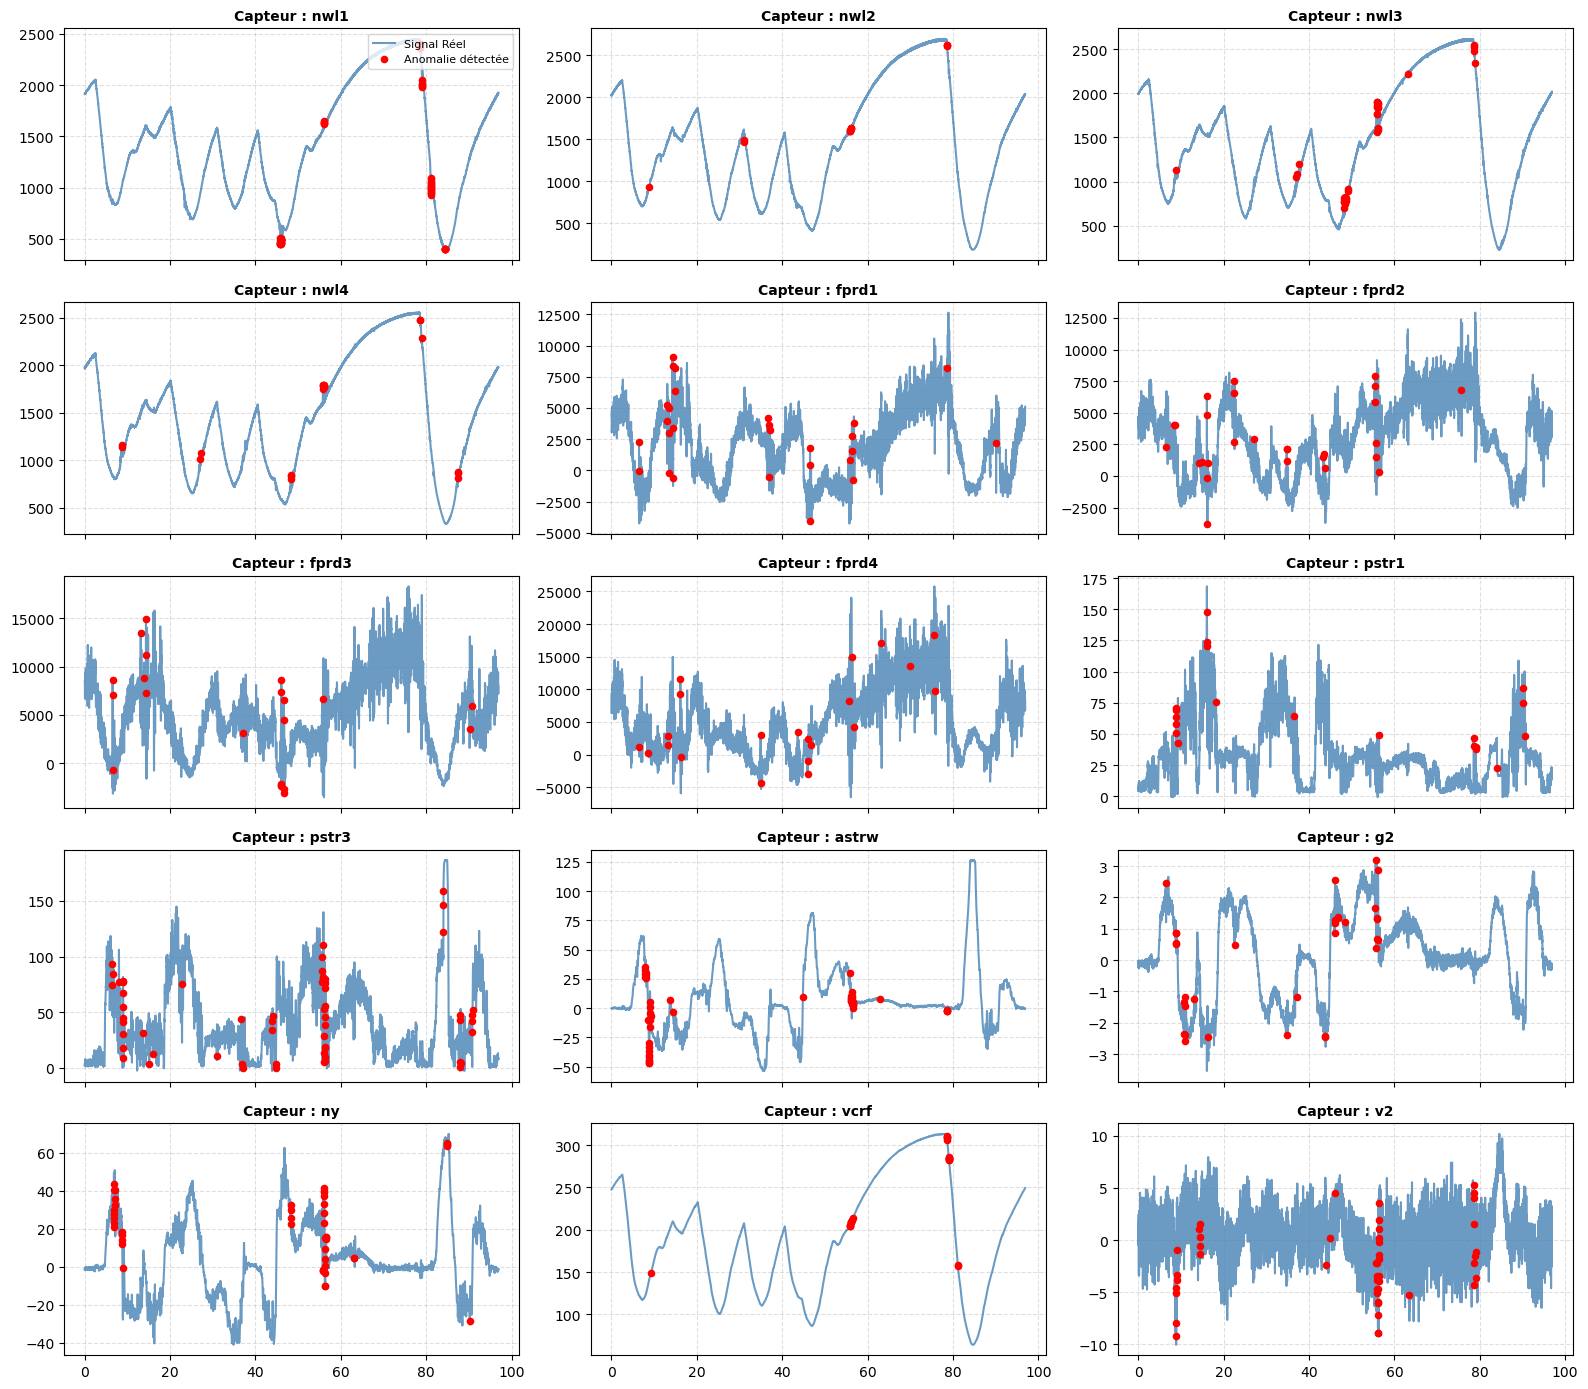

In [20]:

erreur_mse_session = np.power(X_reel_norm_session - X_pred_norm_session, 2)


alertes_matrice1 = erreur_mse_session > seuils_dynamiques

instants_alerte_test1 = np.any(alertes_matrice1, axis=1)

nb_anomalies_totales1 = np.sum(instants_alerte_test1)

print(f"Total des anomalies détectées sur cette session : {np.sum(nb_anomalies_totales1 )}")

visualisation_anomalies_locales_3D(df_final_session, alertes_matrice1, features)

** Conclusion:** On remarque que le modèle comprends mieux les signaux bruités grâce à l'historique. De plus on peut mieux croire le modèle quand il déclare une anomalie car sur deux capteurs symétriques (force appliquée à la roue avant droite et la roue avant gauche) les anomalies détectées sont les mêmes à droite et à gauche ce qui peut confirmer la véracité des anomalies.

## Sur tout le jeux de données de test

In [21]:

X_pred_test_3D = final_history_model.predict(x_test)

X_reel_norm = x_test[:, -1, :]
X_pred_norm = X_pred_test_3D[:, -1, :]

erreur_mse_test = np.power(X_reel_norm - X_pred_norm, 2)


alertes_matrice_test = erreur_mse_test > seuils_dynamiques

instants_alerte_test = np.any(alertes_matrice_test, axis=1)


nb_anomalies_totales1 = np.sum(instants_alerte_test)
total_points_testes1 = len(instants_alerte_test) 
pourcentage_test1 = (nb_anomalies_totales1 / total_points_testes1) * 100


print(f"Total des instants testés   : {total_points_testes1}")
print(f"Total des instants anormaux : {nb_anomalies_totales1}")
print(f"Taux d'anomalie GLOBAL      : {pourcentage_test1:.2f} %")


1792/1792 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Total des instants testés   : 57334
Total des instants anormaux : 2140
Taux d'anomalie GLOBAL      : 3.73 %


# Autre jeu de données

In [22]:
%load_ext autoreload
%autoreload 2

config_dir = "../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id, google_folder_id2, download_dir
add_to_path(join(root_dir, 'src'))
from data_loader import load_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Already in sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [23]:
data_dict2, extracted_dir = load_data(
    file_id=google_folder_id2,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data2.tar",
    pattern="*.csv",
)
print(len(data_dict2), "CSV files loaded")
first_key = next(iter(data_dict2))
print("Example file:", first_key)
print(data_dict2[first_key].head())

list_keys2 = list(data_dict2.keys())
list_session2 = []

for s in list_keys2:
    df = data_dict2[s].copy()
    df_clean = preprocessing.clean_dataframe(df)

    if df_clean.shape[0] != 0:
        
        df_clean['session_id'] = s
        data_dict2[s] = df_clean 
        
        # On sauvegarde le nom dans la liste
        list_session2.append(s)

Extracted data found at: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
Loading CAST data from: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
64 CSV files loaded
Example file: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24\T24S15-04_E-AL10009.csv
                  datetime     nwl1     nwl2     nwl3     nwl4    fprd1  \
0  2024-05-27T06:27:25.884  1758.07  1819.07  1818.91  1804.18  1716.18   
1  2024-05-27T06:27:25.894  1756.17  1824.98  1820.00  1810.42  1689.52   
2  2024-05-27T06:27:25.904  1767.57  1822.61  1815.63  1798.98  1657.06   
3  2024-05-27T06:27:25.914  1765.67  1822.61  1816.72  1801.06  1800.80   
4 

In [24]:
len(list_session2)

58

## Sur toutes les données saines du deuxième circuit

Les circuits proviennent du clustering sur sl'espace réduit d'une PCA réaliser dans le notebook pca.

In [25]:
clean_session2 = joblib.load('models/sessions_saines_circuit2.joblib')
len(clean_session2)

36

In [26]:
total_instants_anormaux_sains = 0
total_instants_testes_sains = 0

for s in clean_session2:
    
    df_run = data_dict2[s].copy()
    

    df_scaled = df_run.copy()
    df_scaled[features] = scaler.transform(df_run[features])

    X_seq = create_sequences(df_scaled, features, time_steps=TIME_STEPS)
    
        
    X_pred_3D = final_history_model.predict(X_seq, verbose=0)
    
   
    X_reel_norm = X_seq[:, -1, :]
    X_pred_norm = X_pred_3D[:, -1, :]
    erreur_mse = np.power(X_reel_norm - X_pred_norm, 2)
    
    alertes_matrice = erreur_mse > seuils_dynamiques
    instants_alerte = np.any(alertes_matrice, axis=1)
    

    total_instants_anormaux_sains += np.sum(instants_alerte)
    total_instants_testes_sains += len(instants_alerte)


    pourcentage_generalisation = (total_instants_anormaux_sains / total_instants_testes_sains) * 100



print(f"Total des points testés       : {total_instants_testes_sains}")
print(f"Total des anomalies détectées : {total_instants_anormaux_sains}")
print(f"Taux d'anomalie global        : {pourcentage_generalisation:.2f} %")


Total des points testés       : 375202
Total des anomalies détectées : 23690
Taux d'anomalie global        : 6.31 %


## Exemple sur une seule session

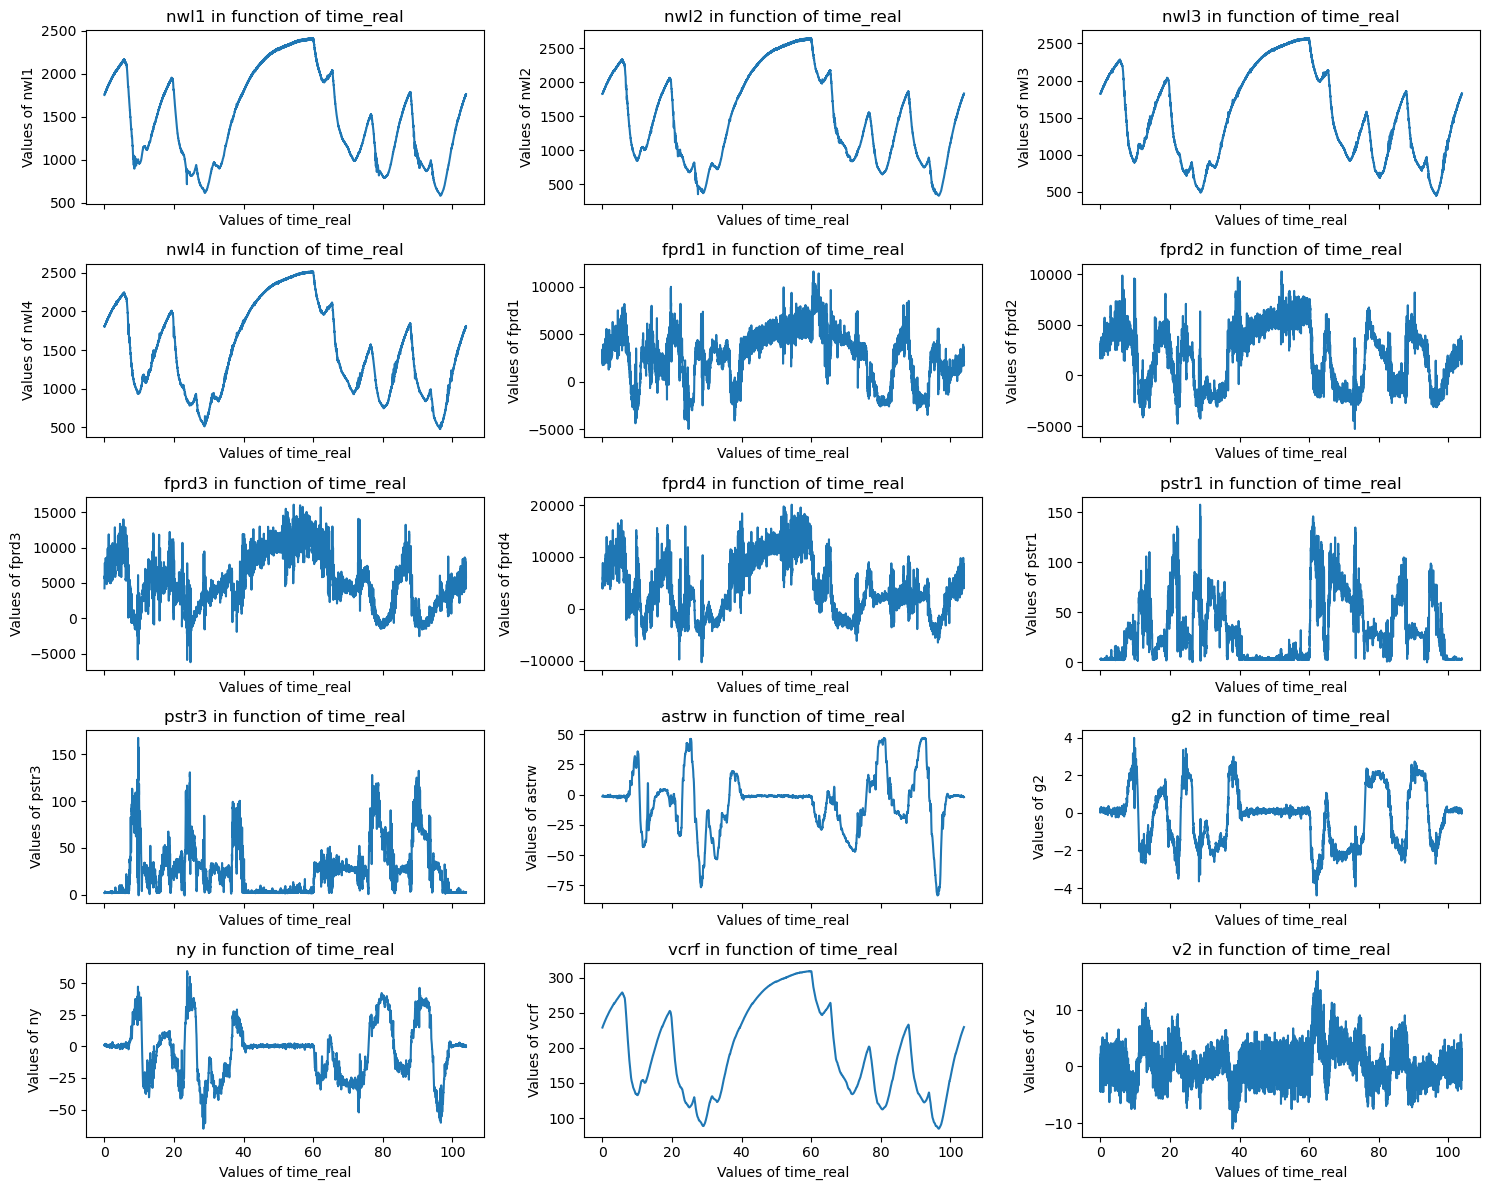

In [29]:
# Visualize a session from the dataset (used for training)
df = data_dict2[clean_session2[7]].copy()
df = preprocessing.clean_dataframe(df)
cols = df.columns[1:-1]
visualisation_plot(df, cols)

In [30]:
nom_session = list_session2[7]

if 'session_id' not in df.columns:
    df['session_id'] = nom_session


In [31]:

df_scaled = df.copy()
df_scaled[features] = scaler.transform(df[features])

X_nouveau_circuit_seq = create_sequences(df_scaled, features, time_steps=TIME_STEPS)


#  PRÉDICTION ET DÉ-NORMALISATION

X_pred_test_3D = final_history_model.predict(X_nouveau_circuit_seq)

n_s, n_t, n_f = X_pred_test_3D.shape
X_pred_2D = X_pred_test_3D.reshape(-1, n_f)
X_pred_unscaled_2D = scaler.inverse_transform(X_pred_2D)
X_pred_unscaled_3D = X_pred_unscaled_2D.reshape(n_s, n_t, n_f)

X_pred_final_all = X_pred_unscaled_3D[:, -1, :] 


325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


C:\Users\fauli\AppData\Local\Temp\ipykernel_22780\2438182869.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df_in.groupby('session_id').apply(lambda x: x.iloc[time_steps-1:]).reset_index(drop=True)


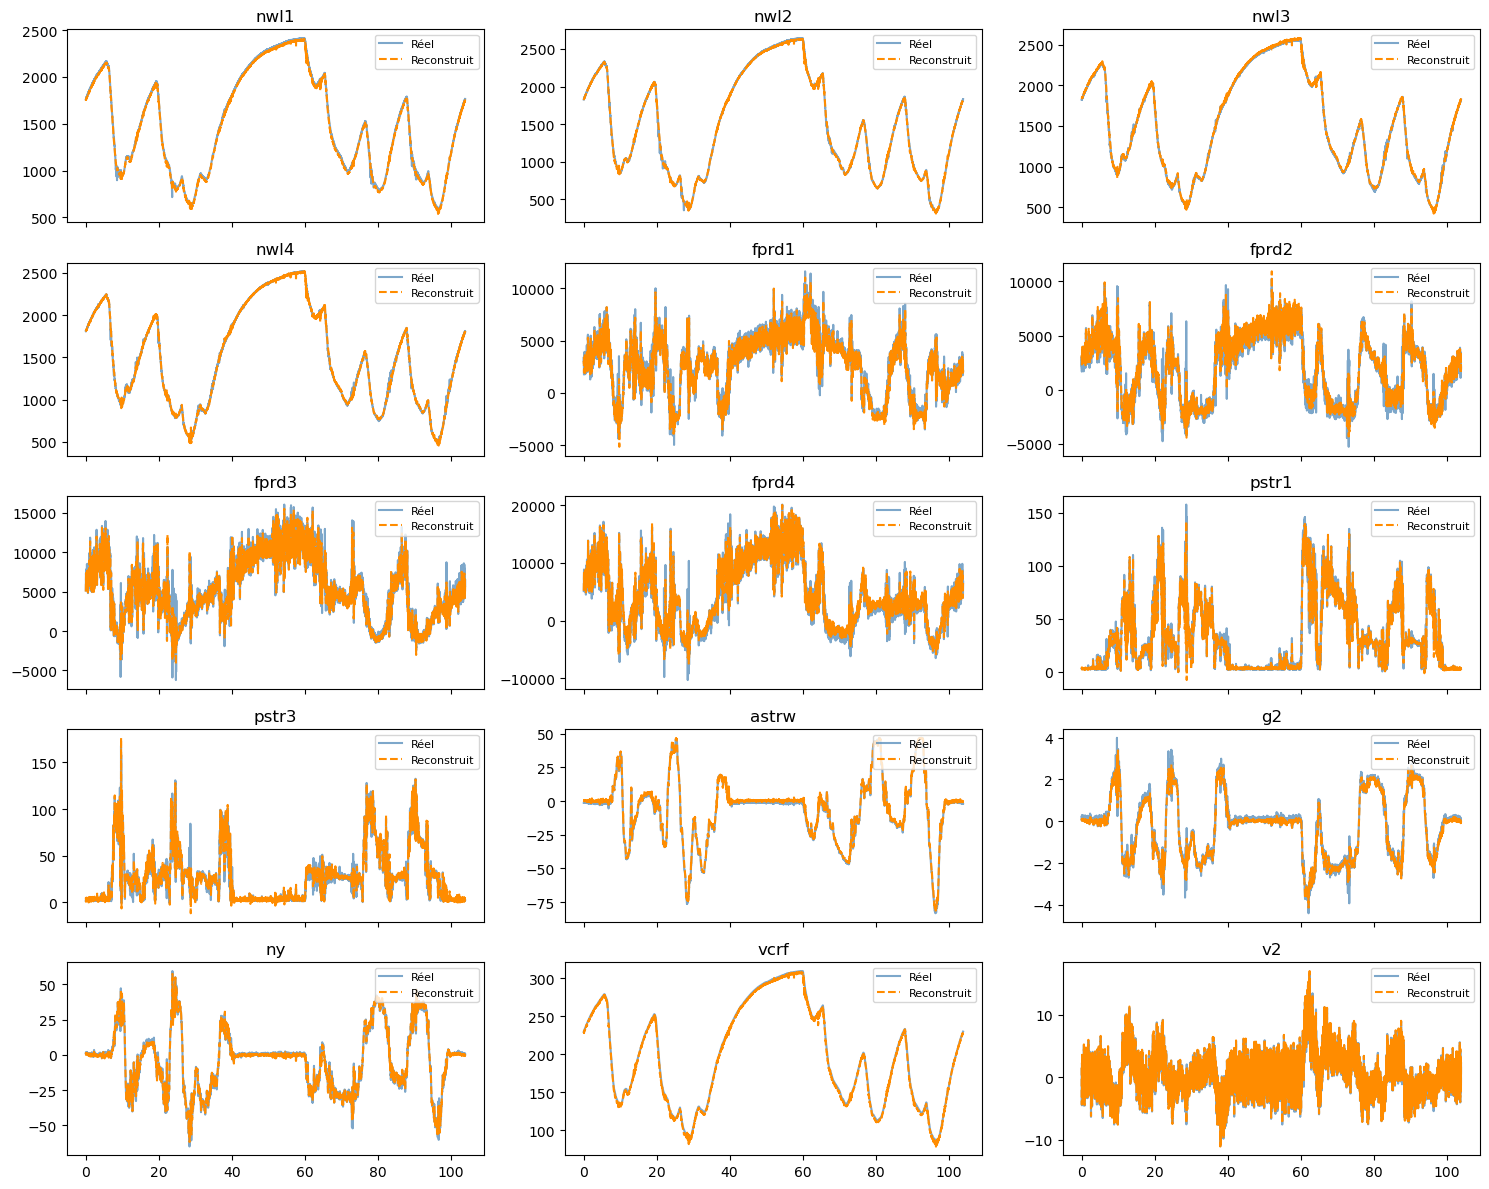

In [32]:
df_plot_all = get_aligned_df(df, time_steps=TIME_STEPS)

target_session = df_plot_all['session_id'].unique()[0] 
mask_session = df_plot_all['session_id'] == target_session

df_final_session2 = df_plot_all[mask_session]
X_pred_session = X_pred_final_all[mask_session.values]


visualisation_plot_nparray(df_final_session2, X_pred_session, features, both=False)

Vérification des tailles - X: 10391 | Y: 10391


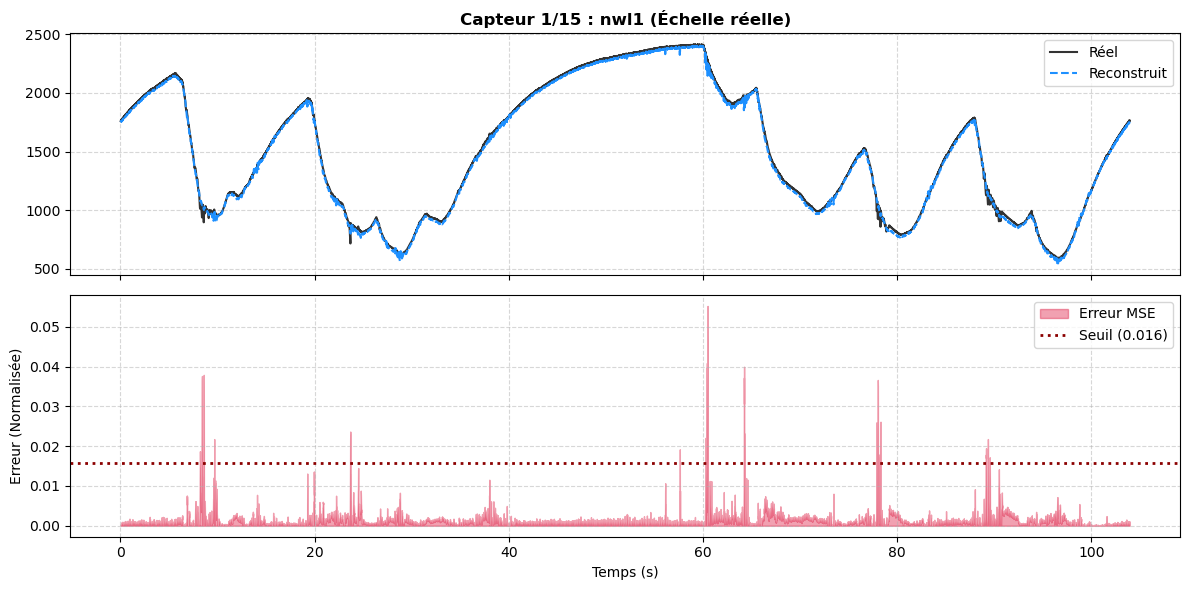

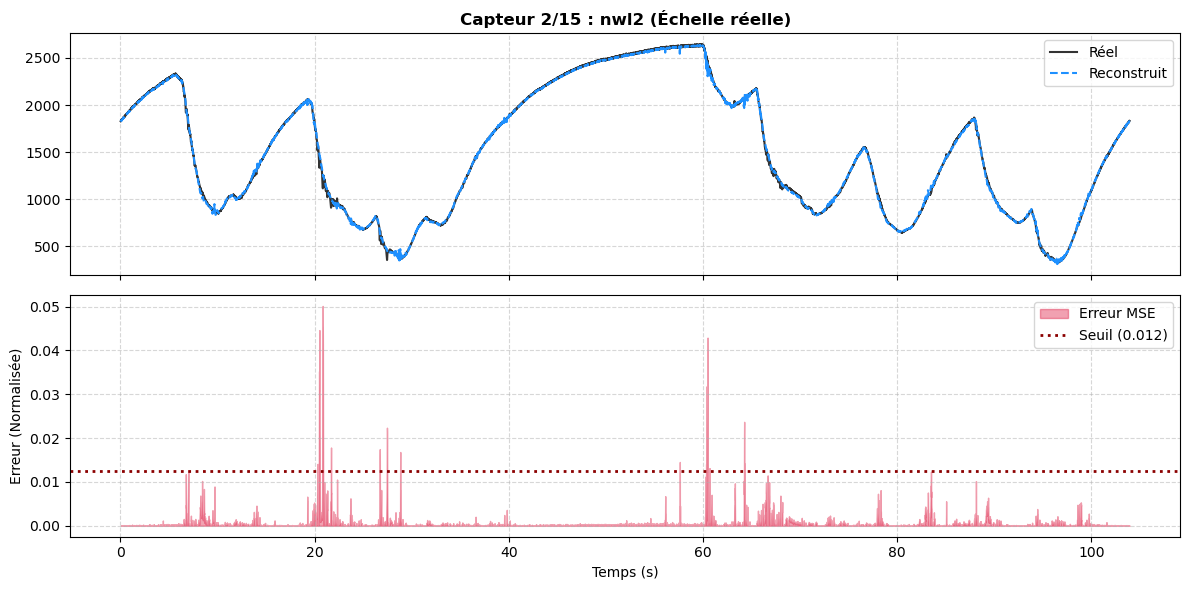

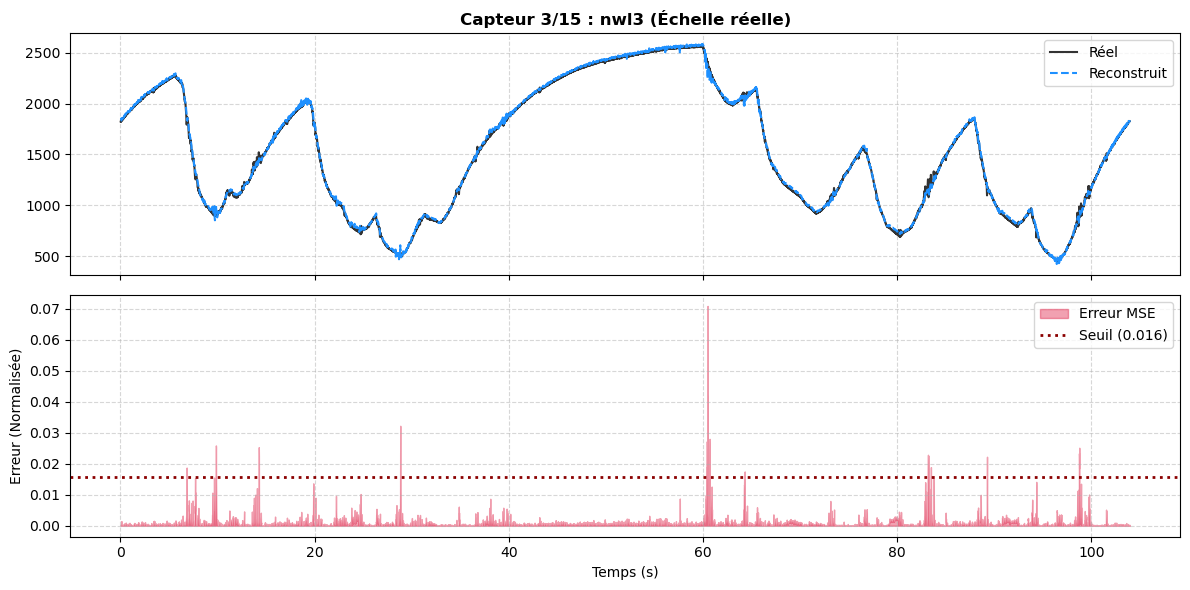

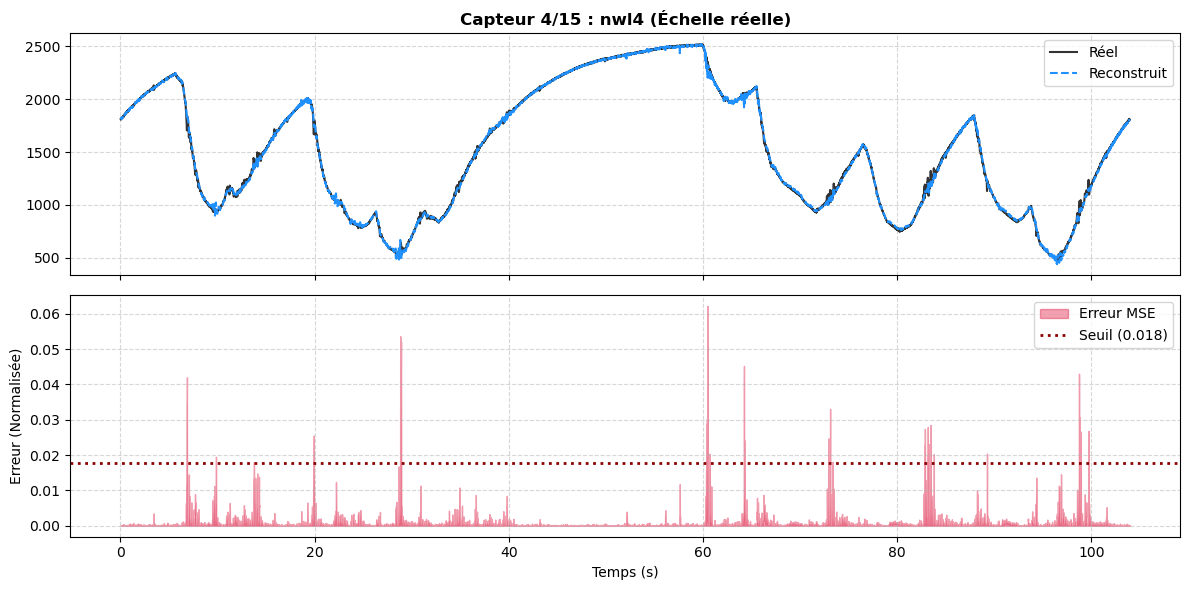

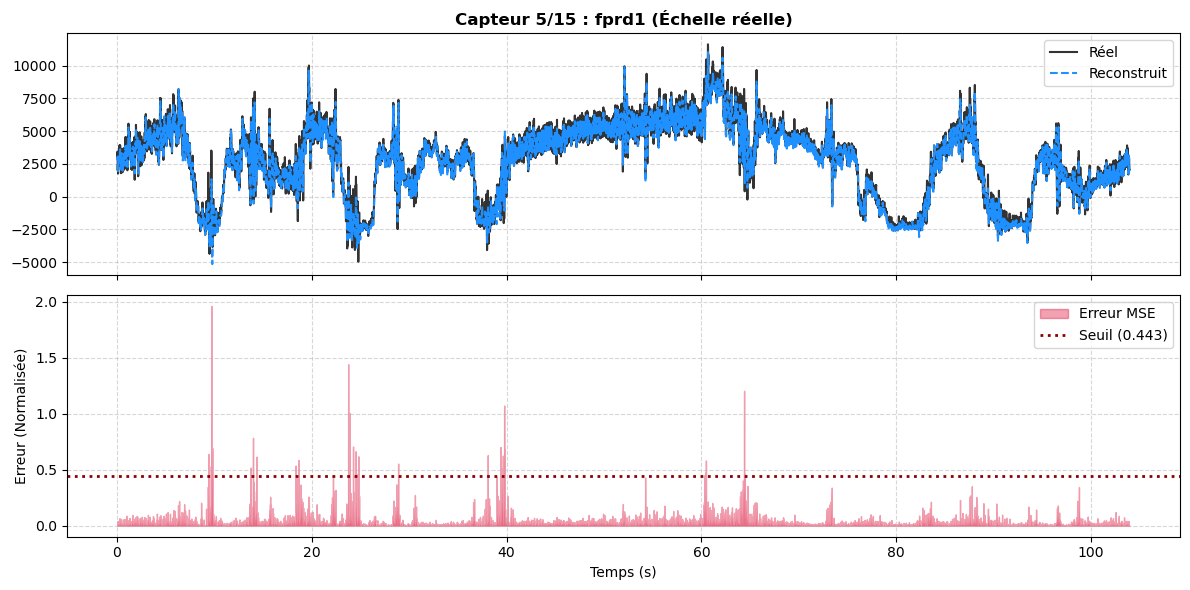

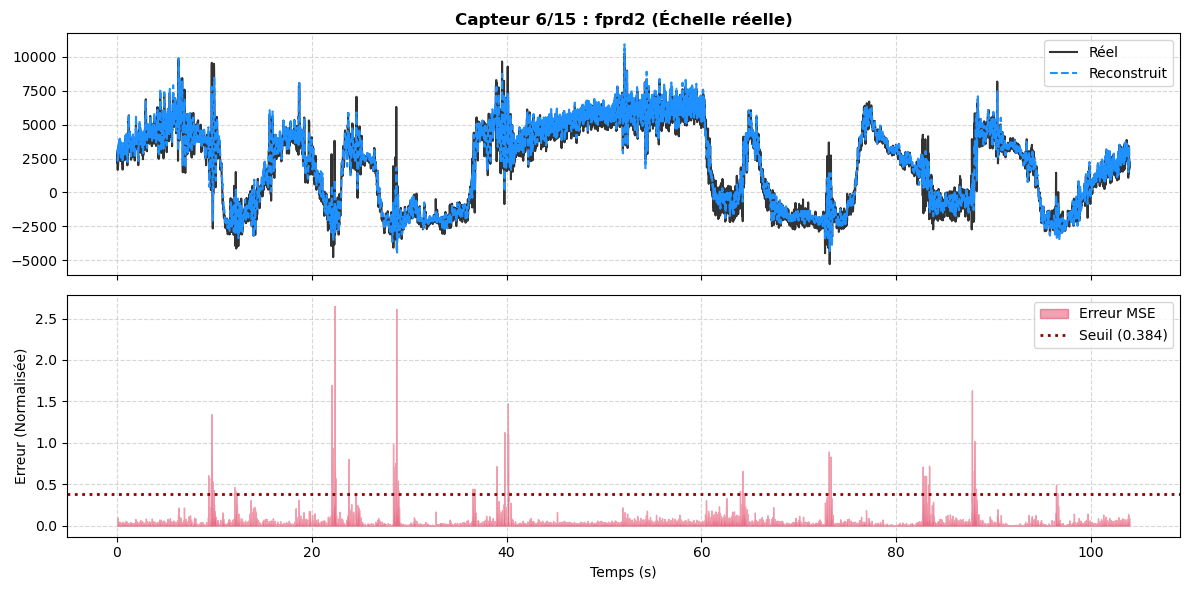

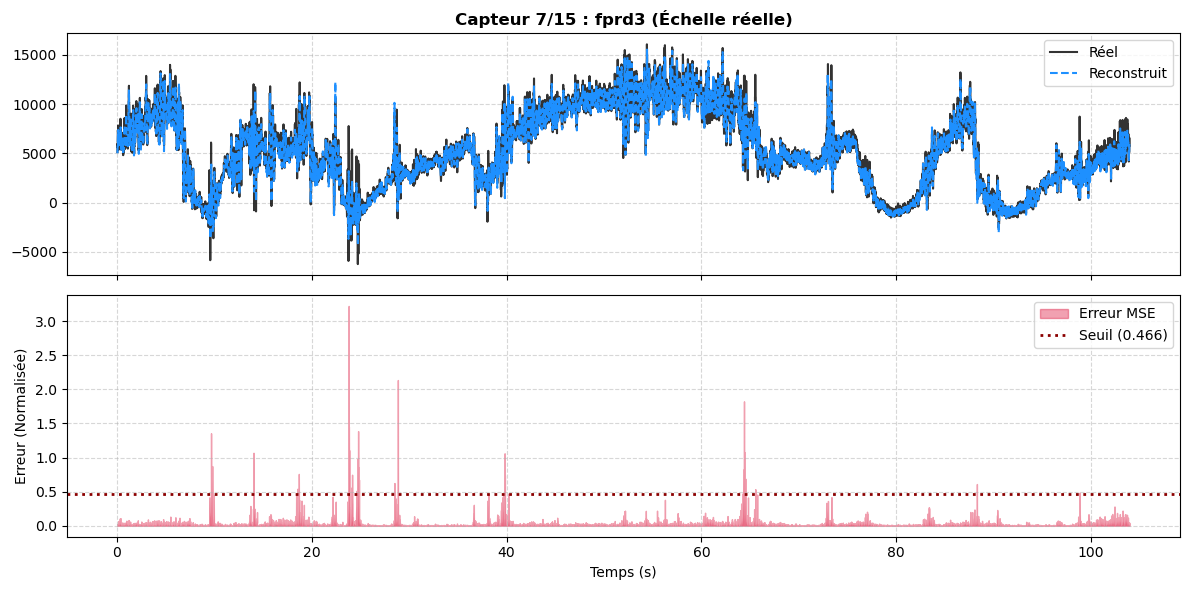

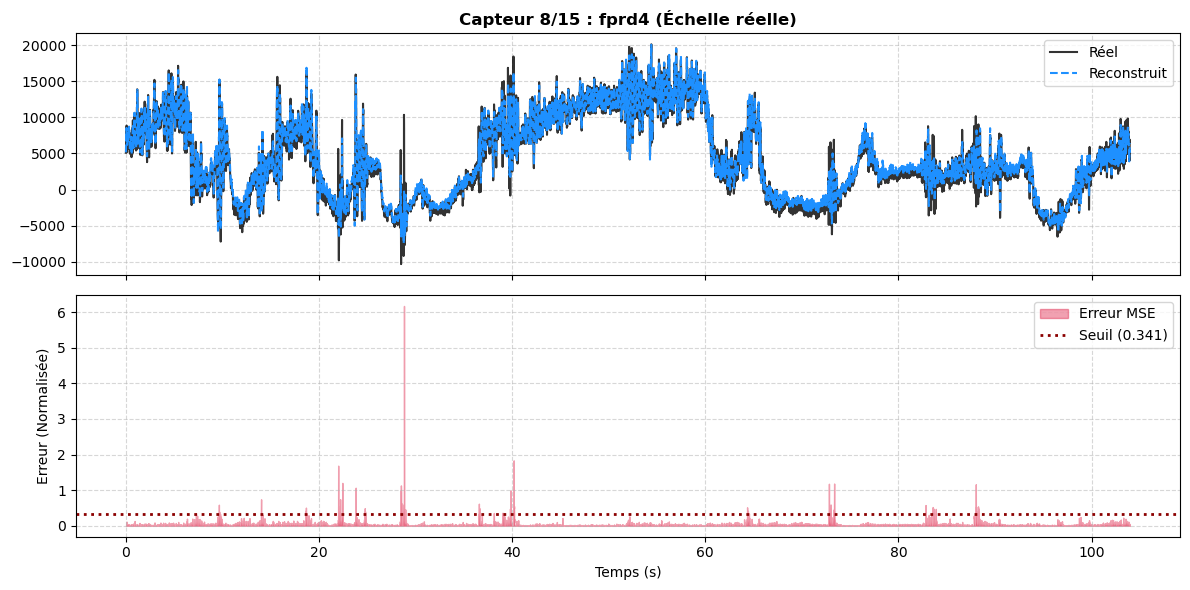

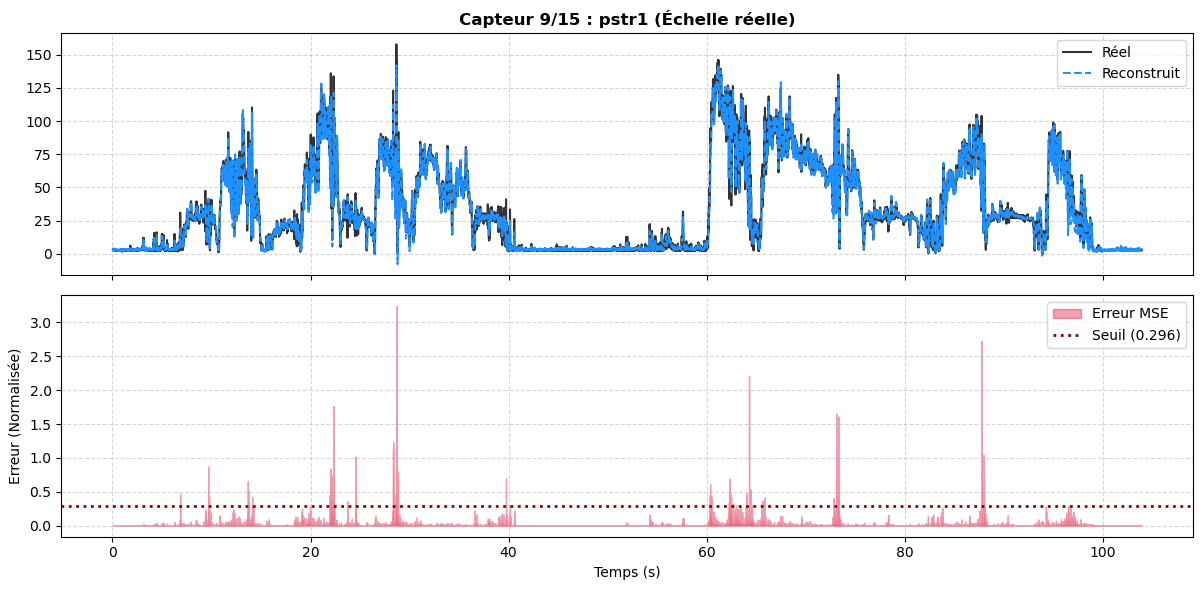

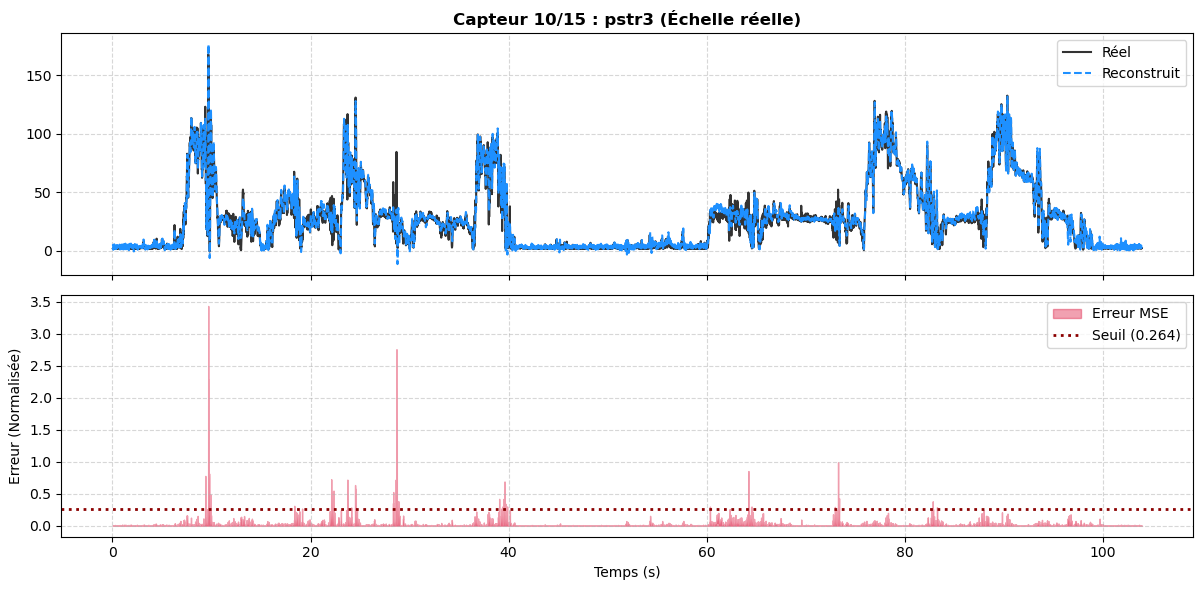

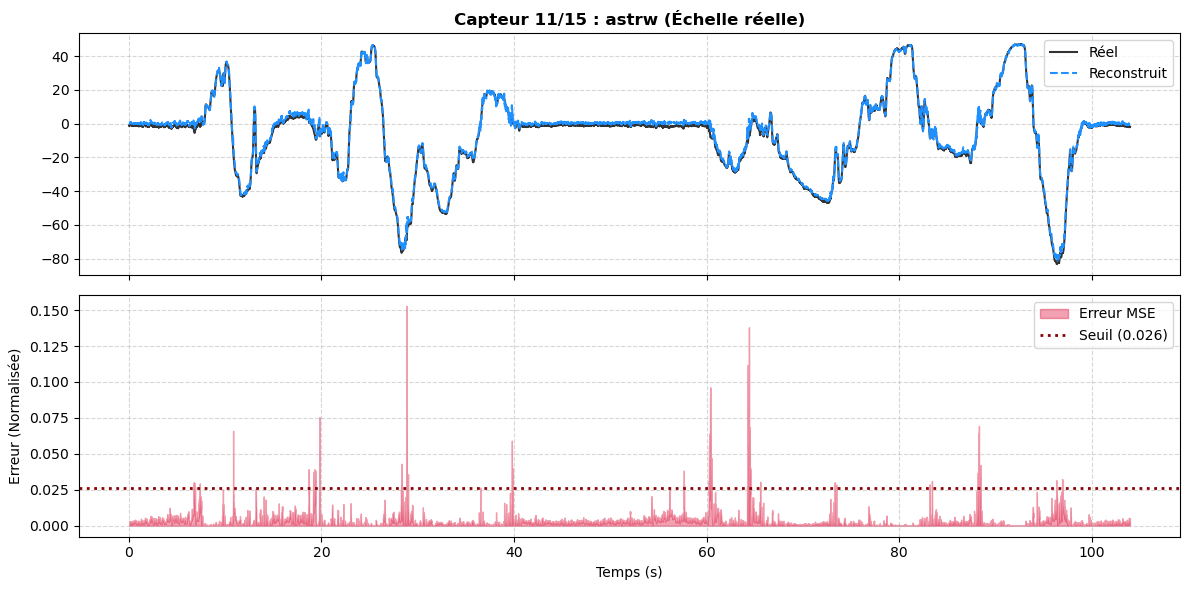

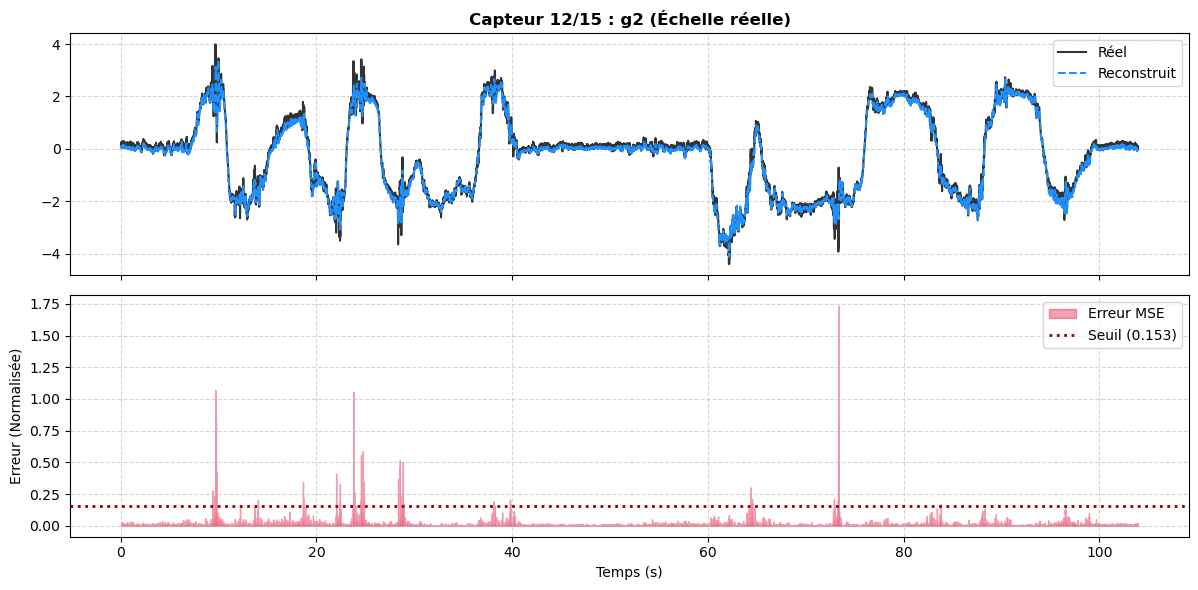

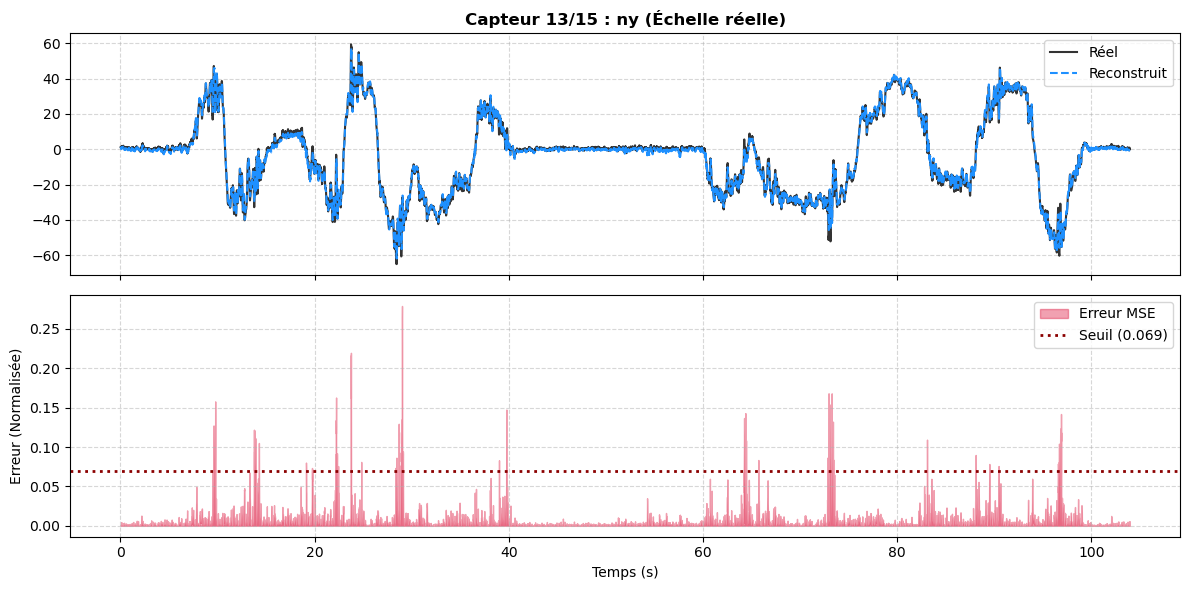

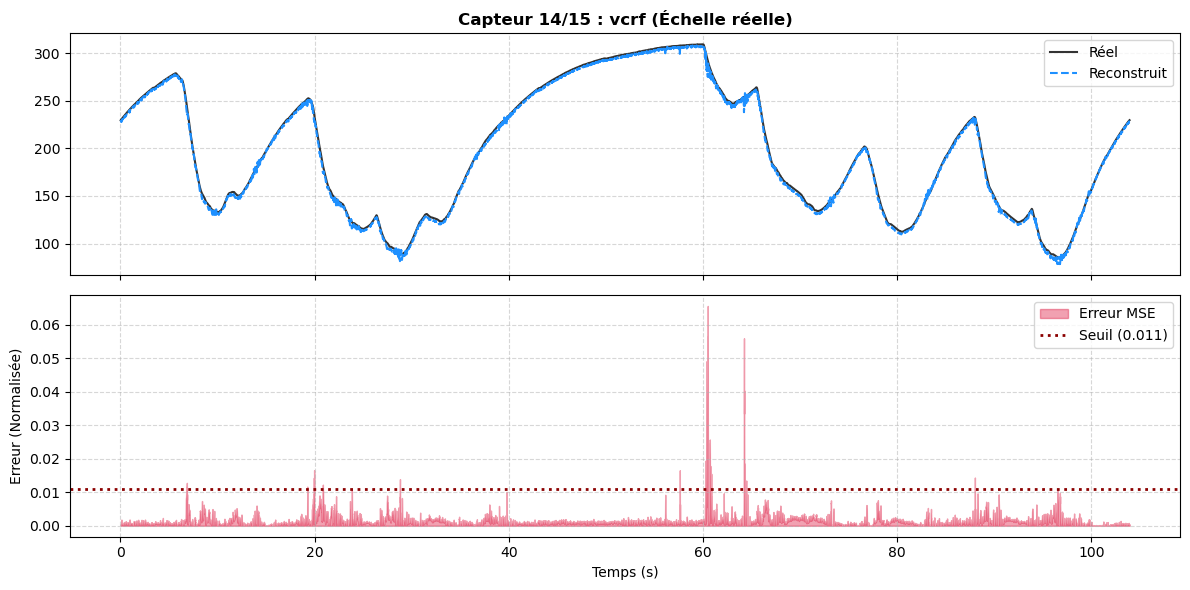

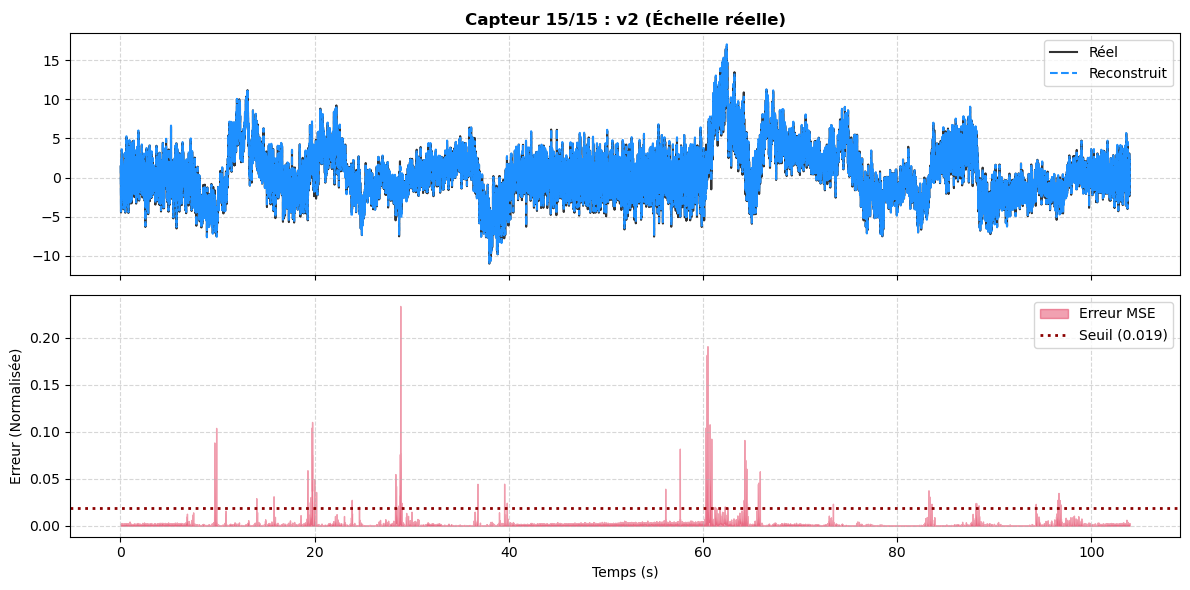

In [33]:
df_final_session2 = df_plot_all[mask_session]
X_pred_session2 = X_pred_final_all[mask_session.values]

X_reel_norm_session2 = X_nouveau_circuit_seq[mask_session.values, -1, :]
X_pred_norm_session2 = X_pred_test_3D[mask_session.values, -1, :]

print(f"Vérification des tailles - X: {len(df_final_session2)} | Y: {len(X_pred_session2)}")

# --- 1. LA BOUCLE SUR LES CAPTEURS ---
for idx, capteur in enumerate(features):
    
   
    signal_reel_physique = df_final_session2[capteur].values
    signal_reconstruit_physique = X_pred_session2[:, idx]
    
    signal_reel_norm = X_reel_norm_session2[:, idx]
    signal_reconstruit_norm = X_pred_norm_session2[:, idx]
    
  
    erreur_locale_mse = np.power(signal_reel_norm - signal_reconstruit_norm, 2)
    seuil_actuel = seuils_dynamiques[idx]
    
    # --- 2. CRÉATION DE LA FIGURE ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # --- GRAPHIQUE HAUT : Signaux Physiques ---
    ax1.plot(df_final_session2['time_real'], signal_reel_physique, label='Réel', color='black', alpha=0.8)
    ax1.plot(df_final_session2['time_real'], signal_reconstruit_physique, label='Reconstruit', color='dodgerblue', linestyle='--')
    ax1.set_title(f"Capteur {idx + 1}/{len(features)} : {capteur} (Échelle réelle)", fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # --- GRAPHIQUE BAS : Erreur et Détection ---
    ax2.fill_between(df_final_session2['time_real'], erreur_locale_mse, color='crimson', alpha=0.4, label='Erreur MSE')
    ax2.axhline(y=seuil_actuel, color='darkred', linestyle=':', linewidth=2, label=f'Seuil ({seuil_actuel:.3f})')
    
   
    ax2.set_ylabel("Erreur (Normalisée)")
    ax2.set_xlabel("Temps (s)")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

Total des anomalies détectées sur cette session : 1108


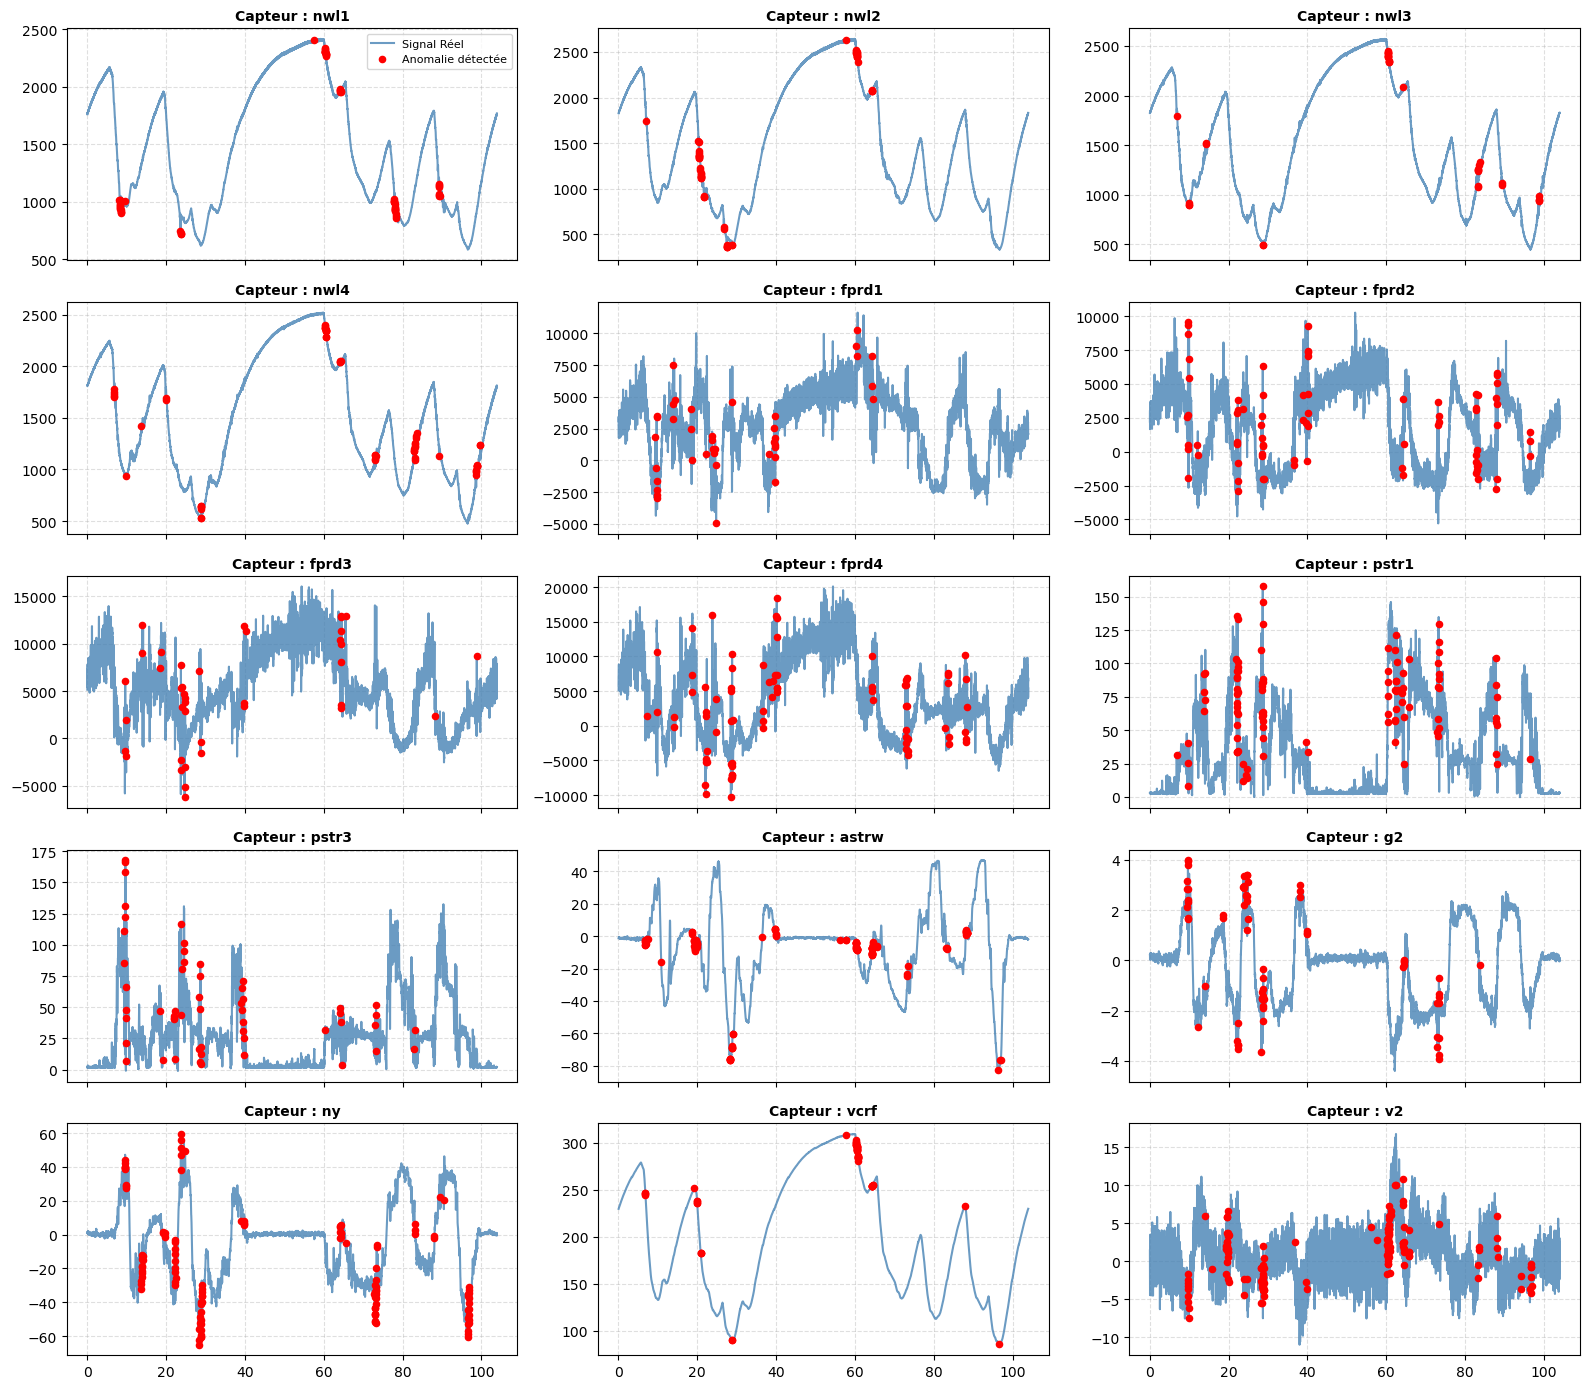

In [34]:

erreur_mse_historique = np.power(X_reel_norm_session2 - X_pred_norm_session2, 2)


alertes_matrice_historique = erreur_mse_historique > seuils_dynamiques

print(f"Total des anomalies détectées sur cette session : {np.sum(alertes_matrice_historique)}")

visualisation_anomalies_locales_3D(df_final_session2, alertes_matrice_historique, features)

# Conclusion

In [35]:
print(f" Le taux d'anomalie global du premier circuit est de : {pourcentage_test1:.2f} %")
print(f" Le taux d'anomalie global du deuxième circuit est de : {pourcentage_generalisation:.2f} %")

 Le taux d'anomalie global du premier circuit est de : 3.73 %
 Le taux d'anomalie global du deuxième circuit est de : 6.31 %


**Conclusion**:
L'évaluation de cet Autoencodeur avec historique a un taux d'anomalie sur le dataset de test de 3.73 % sur le circuit utiliser lors de l'entraînement (Circuit 1) et de 6.31 % sur un jeu de données déterminé comme sain (ACP+ACH) provenant du deuxième circuit. Ce petit écart  démontre une bonne capacité de généralisation de l'algorithme. On peut donc en déduire que le modèle ne réalise pas d'overfitting sur un nouveau circuit en étant robuste sur des données jugées "saines". Cependant on peu se demander quelle est la cause de cette augmentation d'anomalies détectées:
- Est-ce dû à la méthode de détection de sessions jugées comme saines?
- Est-ce dû malgré tout à un manque d'efficacité de notre modèle avec historique?

In [34]:
def get_anomaly_report(df_input, model, features, thresholds, persistence=5, time_steps=10):
    """
    Calcule le taux d'anomalies persistantes pour chaque session du dataframe.
    """
    results = []
    sessions = df_input['session_id'].unique()
    
    for session_id in sessions:
        df_session = df_input[df_input['session_id'] == session_id]
        
        # 1. Création des séquences
        x_session = create_sequences(df_session, features, time_steps)
        if len(x_session) == 0: continue # Sécurité session trop courte
        
        # 2. Prédiction (Inférence)
        x_pred = model.predict(x_session, verbose=0)
        
        # 3. Calcul de l'erreur MAE point par point (on garde le milieu : index 5)
        # On compare le point réel au milieu et sa reconstruction au milieu
        mid_idx = time_steps // 2
        errors = np.abs(x_pred[:, mid_idx, :] - x_session[:, mid_idx, :])
        
        session_report = {'session_id': session_id}
        
        for i, col in enumerate(features):
            # Calcul de la persistance sur l'erreur du capteur i
            is_above = errors[:, i] > thresholds[i]
            persistent_mask = np.convolve(is_above.astype(int), np.ones(persistence), mode='valid') == persistence
            count = np.sum(persistent_mask)
            
            # Taux en %
            rate = (count / len(errors)) * 100
            session_report[col] = round(rate, 2)
            
        results.append(session_report)
    
    return pd.DataFrame(results).set_index('session_id')

def plot_anomaly_heatmap(df_report, title="Analyse des Anomalies"):
    """
    Affiche la heatmap à partir d'un rapport d'anomalies.
    """
    plt.figure(figsize=(15, 7))
    sns.heatmap(df_report, annot=True, cmap='YlOrRd', fmt=".1f", cbar_kws={'label': '% Anomalies'})
    plt.title(title)
    plt.ylabel("Session ID")
    plt.xlabel("Capteurs")
    plt.xticks(rotation=45)
    plt.show()


# Save the model

In [ ]:
import os
import joblib
from tensorflow.keras.models import load_model

# 1. Créer le dossier s'il n'existe pas
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Sauvegarder le modèle (architecture + poids)
model_dnn.save('models/DNN_autoencoder.keras')

# 3. Sauvegarder le scaler (indispensable pour les futures prédictions)
joblib.dump(scaler, 'models/scaler_DNN_autoencoder.pkl')



Modèle et Scaler sauvegardés dans le dossier 'models/' !


In [ ]:
#to call the model and the scaler do
# model = load_model('models/DNN_autoencoder.keras')
# scaler = joblib.load('models/scaler_DNN_autoencoder.pkl') 

# X_new_scaled = scaler.transform(X_new) 

# reconstructions = model.predict(X_new_scaled)